# Logistic regression: human-designed features for friendship prediction

**Research question this notebook serves:** *Can learned representations of social interactions outperform manually engineered behavioral features for friendship prediction?*

This notebook builds the **human-designed-features** arm of that comparison. `nn.ipynb` builds the counterpart **learned-representations** arm (Node2Vec graph embeddings feeding MLP / XGBoost classifiers on the SMS, calls, and proximity graphs). Both arms predict the same label — `is_fb_friend` — from the same four weeks of Copenhagen Networks Study interaction data, so their held-out performance is directly comparable.

A second thing this notebook produces, useful for the interpretability sub-question ("which forms of interaction best reveal meaningful relationships?"), is a **logistic regression coefficient table** — the model-coefficient flavor of feature importance. This is a natural counterpart to whatever feature-importance / ablation numbers come out of the tree-based and embedding models.

*Note: this notebook explains the data pipeline, leakage-avoidance choices, and how to read the results. The conceptual explanation of how logistic regression itself works (the sigmoid, log-odds, maximum likelihood, etc.) is intentionally left out — that part of the presentation is being written separately.*

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score, brier_score_loss,
    f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

PAIR_KEYS = ['user_a', 'user_b']
RANDOM_STATE = 42

cwd = Path.cwd()
if (cwd / 'FinalProject' / 'data' / 'processed').exists():
    PROJECT_DIR = cwd / 'FinalProject'
elif (cwd / 'data' / 'processed').exists():
    PROJECT_DIR = cwd
elif (cwd.parent / 'data' / 'processed').exists():
    PROJECT_DIR = cwd.parent
else:
    raise FileNotFoundError('Could not locate FinalProject/data/processed.')

DATA_DIR = PROJECT_DIR / 'data' / 'processed'
FIGURE_DIR = PROJECT_DIR / 'website_assets' / 'eda'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, GREEN, VIOLET = '#2A78D6', '#EB6834', '#1BAF7A', '#4A3AA7'
GREY, LIGHT_GREY, INK = '#8A8984', '#E6E5DF', '#171717'
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'figure.dpi': 110})

def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    print(f'Saved: {path}')

## 1. Load the prepared model inputs

Rather than re-deriving features from raw interaction logs here, this notebook reads the outputs of the feature-engineering pipeline (`csvMerge.ipynb`) together with the manifests that document *what every column means, whether it's safe to use, and how it should be transformed*. Building the model straight from those manifests (instead of hardcoding a feature list) means the modeling step stays honest about the same leakage rules the feature-engineering step already worked out.

Two model-input tables are provided, and we use both:

- **`logistic_baseline_input.csv`** — all 27 eligible features, including five *general activity controls* (e.g. total texts sent, calls received per day). These were computed from the **full population**, not recomputed per fold, so they carry a small amount of leakage risk across the train/test boundary (flagged as `requires_outer_fold_recompute` in the manifest).
- **`logistic_strict_inductive_input.csv`** — the 22 features that remain after dropping every column that isn't safe under strict participant-disjoint evaluation. This is the leakage-conservative version.

We fit and evaluate both, and treat the gap between them as a diagnostic: if the baseline model meaningfully outperforms the strict-inductive model, that gap is at least partly inflated performance from the leakage-prone controls, not real signal.

In [2]:
baseline_df = pd.read_csv(DATA_DIR / 'logistic_baseline_input.csv')
strict_df = pd.read_csv(DATA_DIR / 'logistic_strict_inductive_input.csv')
manifest = pd.read_csv(DATA_DIR / 'model_feature_manifest.csv')
exclusions = pd.read_csv(DATA_DIR / 'model_exclusion_manifest.csv')
folds = pd.read_csv(DATA_DIR / 'participant_disjoint_folds.csv')

for df in (baseline_df, strict_df):
    if df['is_fb_friend'].dtype == object:
        df['is_fb_friend'] = df['is_fb_friend'].map({'True': True, 'False': False})
    df['is_fb_friend'] = df['is_fb_friend'].astype(bool)
    assert not df[PAIR_KEYS].duplicated().any()
    assert df['user_a'].lt(df['user_b']).all()

fold_map = dict(zip(folds['user'], folds['participant_fold']))
n_folds = folds['participant_fold'].nunique()

print(f'Baseline input:         {len(baseline_df):,} pairs, {baseline_df.shape[1] - 3} features')
print(f'Strict-inductive input: {len(strict_df):,} pairs, {strict_df.shape[1] - 3} features')
print(f'Friend prevalence (baseline table): {baseline_df["is_fb_friend"].mean():.2%}')
print(f'Participant folds: {n_folds} disjoint folds covering {folds.shape[0]:,} participants')

Baseline input:         79,692 pairs, 27 features
Strict-inductive input: 79,692 pairs, 22 features
Friend prevalence (baseline table): 4.09%
Participant folds: 5 disjoint folds covering 742 participants


## 2. Why the features are excluded that are excluded

Before picking a feature list by hand, it's worth looking at what the feature-engineering pass already ruled out and why. These are exact duplicates, derived-from-the-label columns, identifiers, or fields that are undefined for part of the population — keeping them would either leak the label back into the model or silently double-count a signal.

In [3]:
display(exclusions)

,column,reason
0,user_a,identifier; split key only
1,user_b,identifier; split key only
2,is_fb_friend,target
3,behavior_candidate,"population filter, not a behavioral strength f..."
4,behavior_roster_pair,population filter for the label-independent al...
5,has_any_pair_interaction,constant inside the primary behavior-candidate...
6,user_a_daily_texts_received,endpoint component; use the symmetric combined...
7,user_b_daily_texts_received,endpoint component; use the symmetric combined...
8,mutual_friends,derived from the outcome graph unless rebuilt ...
9,total_facebook_friend_count,derived from the outcome graph


## 3. Fold-local preprocessing, driven by the manifest

Two rules that matter for a dataset like this:

1. **Skewed count features need `log1p`.** Contact minutes, text counts, call counts, and streak lengths are heavily right-skewed — a handful of very active pairs would otherwise dominate the scaled feature. `log1p` compresses that without breaking at zero.
2. **Imputation and scaling must be *fold-local*.** Several features (proximity RSSI, reciprocity, call duration) are only defined when a pair actually interacted, so they're missing for pairs that never called or never came within Bluetooth range. Filling those gaps with the population median, or fitting a `StandardScaler` on the full dataset, would leak test-fold statistics into the training fold. Instead, the median and the scaler are fit **only on the current fold's training pairs**, then applied to that fold's held-out pairs.

The `future_transform` column in the manifest already specifies which of these steps each feature needs, so the preprocessing function below reads that instead of hardcoding a feature list — if the feature-engineering notebook adds or reclassifies a column, this modeling step picks it up automatically.

In [4]:
def parse_transform_spec(text):
    text = text.lower()
    return {
        'impute': 'imputation' in text,
        'log1p': 'log1p' in text,
        'scale': 'scaling' in text,
    }

primary_features = (
    manifest[manifest['eligible_for_primary_model']]
    .sort_values('primary_model_order')
    .reset_index(drop=True)
)
FEATURE_SPECS = {row.column: parse_transform_spec(row.future_transform) for row in primary_features.itertuples()}

STRICT_COLUMNS = [c for c in primary_features['column'] if primary_features.set_index('column').loc[c, 'safe_for_strict_inductive_as_exported']]
BASELINE_COLUMNS = list(primary_features['column'])

print(f'{len(STRICT_COLUMNS)} strict-inductive features, {len(BASELINE_COLUMNS)} baseline features')
display(primary_features[['column', 'role', 'future_transform', 'safe_for_strict_inductive_as_exported']])

22 strict-inductive features, 27 baseline features


,column,role,future_transform,safe_for_strict_inductive_as_exported
0,in_person_contact_minutes,direct pair evidence,log1p + fold-local scaling,True
1,average_proximity_rssi,direct pair evidence,fold-local imputation + scaling,True
2,proximity_measurements,direct pair evidence,log1p + fold-local scaling,True
3,has_proximity_measurement,direct pair evidence,binary; no scaling,True
4,fraction_rssi_above_threshold,direct pair evidence,fold-local imputation + scaling,True
5,texts_shared,direct pair evidence,log1p + fold-local scaling,True
6,has_text_exchange,direct pair evidence,binary; no scaling,True
7,days_texted,direct pair evidence,log1p + fold-local scaling,True
8,text_reciprocity,direct pair evidence,fold-local imputation + scaling,True
9,total_calls,direct pair evidence,log1p + fold-local scaling,True


In [5]:
def fit_transform_fold(train_frame, test_frame, columns, specs, clip_z=5.0):
    """Fit imputation/scaling on the training fold only; apply to both folds."""
    train_X = train_frame[columns].copy()
    test_X = test_frame[columns].copy()

    for column in columns:
        spec = specs[column]
        if spec['impute']:
            median = train_X[column].median()
            train_X[column] = train_X[column].fillna(median)
            test_X[column] = test_X[column].fillna(median)
        if spec['log1p']:
            train_X[column] = np.log1p(train_X[column].clip(lower=0))
            test_X[column] = np.log1p(test_X[column].clip(lower=0))

    scale_columns = [c for c in columns if specs[c]['scale']]
    if scale_columns:
        scaler = StandardScaler()
        train_X[scale_columns] = scaler.fit_transform(train_X[scale_columns])
        test_X[scale_columns] = scaler.transform(test_X[scale_columns])
        # A handful of features (e.g. reciprocity) are only defined for well under 1%
        # of pairs. After fold-local median imputation almost every row is identical,
        # so the tiny leftover variance from the few real values inflates their
        # standardized scores to 30-40+ std deviations. That doesn't throw an error,
        # but it destabilizes the solver (matmul overflow warnings while fitting) and
        # gives a handful of rows outsized leverage. Clipping to +/-5 std keeps the
        # ranking information while removing the pathological leverage.
        train_X[scale_columns] = train_X[scale_columns].clip(lower=-clip_z, upper=clip_z)
        test_X[scale_columns] = test_X[scale_columns].clip(lower=-clip_z, upper=clip_z)

    return train_X, test_X

## 4. Participant-disjoint cross-validation

A random 80/20 split over **pairs** can put the same participant in both the training and test sets (e.g. `(3, 7)` in training, `(3, 91)` in testing) — the model can then partly identify person 3 rather than learn a general interaction pattern, and performance looks better than it would on genuinely new people.

`participant_disjoint_folds.csv` assigns every participant to exactly one of five folds. For each outer fold *k*:

- **Test set:** pairs where *both* participants are in fold *k*.
- **Train set:** pairs where *neither* participant is in fold *k*.
- **Dropped:** pairs that straddle the boundary (one participant in fold *k*, the other not) — these are excluded from both sides for that fold, since they're neither a clean train example nor a clean test example.

Rotating *k* through all five folds gives five honest train/test splits from a single, fixed, reproducible partition — no repeated random resampling required, and every participant serves as a held-out test subject exactly once.

In [6]:
def fold_masks(df, k):
    a_fold = df['user_a'].map(fold_map)
    b_fold = df['user_b'].map(fold_map)
    train_mask = (a_fold != k) & (b_fold != k)
    test_mask = (a_fold == k) & (b_fold == k)
    return train_mask, test_mask

for k in range(n_folds):
    train_mask, test_mask = fold_masks(strict_df, k)
    dropped = len(strict_df) - train_mask.sum() - test_mask.sum()
    print(f'Fold {k}: {train_mask.sum():,} train pairs, {test_mask.sum():,} test pairs, {dropped:,} boundary pairs dropped')

Fold 0: 50,728 train pairs, 3,261 test pairs, 25,703 boundary pairs dropped
Fold 1: 50,926 train pairs, 3,169 test pairs, 25,597 boundary pairs dropped
Fold 2: 51,123 train pairs, 3,185 test pairs, 25,384 boundary pairs dropped
Fold 3: 51,546 train pairs, 2,962 test pairs, 25,184 boundary pairs dropped
Fold 4: 50,542 train pairs, 3,212 test pairs, 25,938 boundary pairs dropped


## 5. Cross-validated performance: strict-inductive vs. baseline

For each of the five outer folds, and for both feature sets, we fit `LogisticRegression(class_weight='balanced')` on the fold's training pairs and score it on that fold's held-out pairs. `class_weight='balanced'` matters here because friendship is rare relative to all possible pairs — without it, the model could get a deceptively low loss by predicting "not friends" for almost everyone.

Seven metrics, because any one alone can mislead on an imbalanced label:

- **ROC-AUC** — probability a random friend pair is ranked above a random non-friend pair. 0.50 is random ranking.
- **Gini coefficient** — a linear rescaling of ROC-AUC (`Gini = 2 × ROC-AUC − 1`), so 0 is random and 1 is perfect ranking. Carries exactly the same information as ROC-AUC; included because it's the standard discrimination metric in credit-scoring/churn-style modeling, where "AUC" and "Gini" are often used interchangeably by convention.
- **Average precision (AP)** — area under the precision-recall curve. Its random baseline is the friend prevalence itself (not 0.50), so we report the **lift over that baseline** as the more interpretable number.
- **Accuracy** — the fraction of held-out pairs classified correctly at the model's default 0.5 probability threshold. This is the plain-language "how often is it right" number, but on its own it's a trap here: with friendship at ~4% prevalence, a model that predicts "not friends" for *every single pair* scores roughly 96% accuracy while catching zero real friendships. Accuracy is reported for that reason, not because it's the metric to optimize.
- **Balanced accuracy** — the average of the true-positive rate and true-negative rate. Unlike raw accuracy, it isn't inflated by the class imbalance, so it's a more honest single-number readout of classification correctness.
- **Precision** — of the pairs the model predicts as "friends," what fraction actually are. Low precision means a lot of false alarms.
- **Recall** — of the pairs that actually are friends, what fraction the model catches. Low recall means real friendships are being missed.

Precision and recall trade off against each other, and `class_weight='balanced'` is one specific point on that tradeoff curve, not the only reasonable choice — Section 5.1 explores what happens when that choice is changed deliberately.


In [7]:
def run_cv(df, columns, label, neg_weight_multiplier=1.0):
    """5-fold participant-disjoint CV. neg_weight_multiplier=1.0 reproduces plain
    class_weight='balanced'; values > 1 make the model more conservative about predicting
    'friend' by penalizing negative-class (non-friend) errors more heavily (see Section 5.1)."""
    rows = []
    for k in range(n_folds):
        train_mask, test_mask = fold_masks(df, k)
        train_frame, test_frame = df.loc[train_mask], df.loc[test_mask]

        train_X, test_X = fit_transform_fold(train_frame, test_frame, columns, FEATURE_SPECS)
        y_train = train_frame['is_fb_friend'].astype(int)
        y_test = test_frame['is_fb_friend'].astype(int)

        neg_weight, pos_weight = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
        class_weight = {0: neg_weight * neg_weight_multiplier, 1: pos_weight}

        model = LogisticRegression(class_weight=class_weight, max_iter=2000, random_state=RANDOM_STATE)
        model.fit(train_X, y_train)
        proba = model.predict_proba(test_X)[:, 1]
        pred = model.predict(test_X)

        rows.append({
            'Feature set': label,
            'Fold': k,
            'Test prevalence': y_test.mean(),
            'ROC-AUC': roc_auc_score(y_test, proba),
            'Average precision': average_precision_score(y_test, proba),
            'Accuracy': accuracy_score(y_test, pred),
            'Balanced accuracy': balanced_accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred, zero_division=0),
            'Recall': recall_score(y_test, pred, zero_division=0),
            'F1': f1_score(y_test, pred, zero_division=0),
        })
    return pd.DataFrame(rows)

strict_results = run_cv(strict_df, STRICT_COLUMNS, 'Strict-inductive (22 features)')
baseline_results = run_cv(baseline_df, BASELINE_COLUMNS, 'Baseline (27 features)')
cv_results = pd.concat([strict_results, baseline_results], ignore_index=True)

cv_summary = (
    cv_results.groupby('Feature set')
    .agg(
        Friend_prevalence=('Test prevalence', 'mean'),
        ROC_AUC=('ROC-AUC', 'mean'),
        ROC_AUC_std=('ROC-AUC', 'std'),
        Average_precision=('Average precision', 'mean'),
        AP_std=('Average precision', 'std'),
        Accuracy=('Accuracy', 'mean'),
        Accuracy_std=('Accuracy', 'std'),
        Balanced_accuracy=('Balanced accuracy', 'mean'),
        Balanced_accuracy_std=('Balanced accuracy', 'std'),
        Precision=('Precision', 'mean'),
        Recall=('Recall', 'mean'),
        F1=('F1', 'mean'),
    )
    .reset_index()
)
cv_summary['AP lift over baseline prevalence'] = cv_summary['Average_precision'] / cv_summary['Friend_prevalence']
# Gini coefficient: a linear rescaling of ROC-AUC (0 = random ranking, 1 = perfect ranking) used
# as the standard discrimination metric in credit-scoring/churn-style modeling. Same information
# as ROC-AUC, different convention -- included here since it's a one-line derivation and some
# audiences expect it by name.
cv_summary['Gini'] = 2 * cv_summary['ROC_AUC'] - 1

display(
    cv_summary.style.format({
        'Friend_prevalence': '{:.2%}', 'ROC_AUC': '{:.3f}', 'ROC_AUC_std': '{:.3f}',
        'Gini': '{:.3f}',
        'Average_precision': '{:.3f}', 'AP_std': '{:.3f}',
        'Accuracy': '{:.1%}', 'Accuracy_std': '{:.1%}',
        'Balanced_accuracy': '{:.1%}', 'Balanced_accuracy_std': '{:.1%}',
        'Precision': '{:.1%}', 'Recall': '{:.1%}', 'F1': '{:.1%}',
        'AP lift over baseline prevalence': '{:.2f}×',
    }).hide(axis='index').set_caption('Mean performance across five participant-disjoint outer folds (default class_weight="balanced")')
)


Feature set,Friend_prevalence,ROC_AUC,ROC_AUC_std,Average_precision,AP_std,Accuracy,Accuracy_std,Balanced_accuracy,Balanced_accuracy_std,Precision,Recall,F1,AP lift over baseline prevalence,Gini
Baseline (27 features),4.17%,0.843,0.026,0.480,0.025,84.5%,1.4%,78.9%,2.4%,17.5%,72.7%,28.2%,11.52×,0.686
Strict-inductive (22 features),4.17%,0.838,0.023,0.480,0.027,84.7%,0.9%,79.4%,2.5%,17.8%,73.7%,28.6%,11.50×,0.676


Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_cv_performance.png


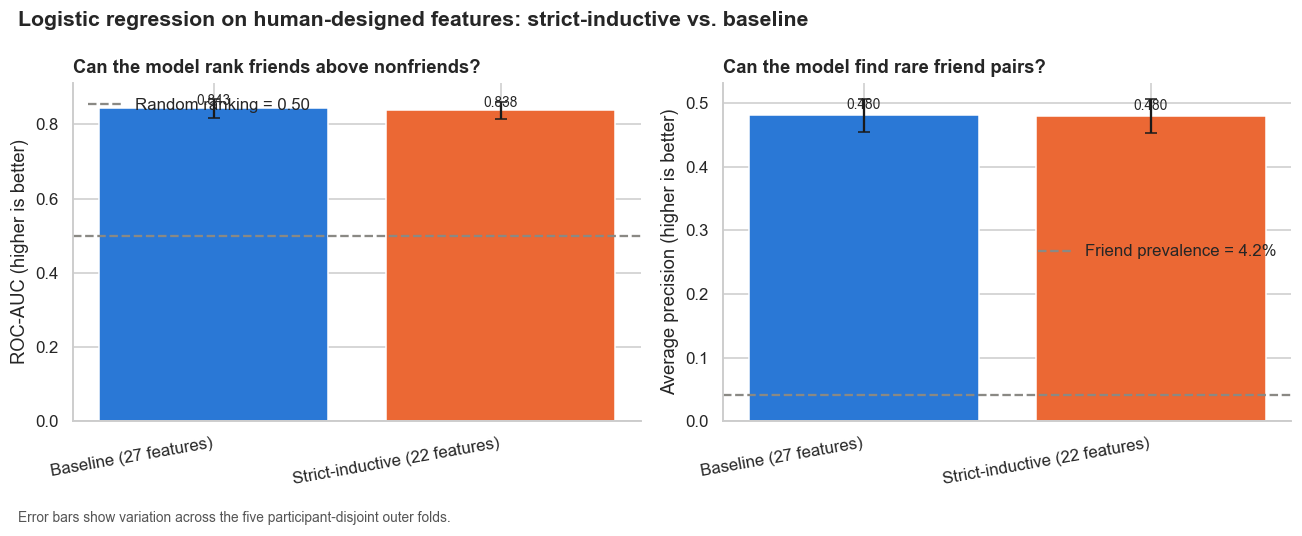

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
colors = [BLUE, ORANGE]
x = np.arange(len(cv_summary))

axes[0].bar(x, cv_summary['ROC_AUC'], yerr=cv_summary['ROC_AUC_std'], color=colors, capsize=4)
axes[0].axhline(0.5, color=GREY, linestyle='--', label='Random ranking = 0.50')
axes[0].set_ylabel('ROC-AUC (higher is better)')
axes[0].set_title('Can the model rank friends above nonfriends?', loc='left', fontweight='bold')
axes[0].legend(frameon=False, loc='upper left')

axes[1].bar(x, cv_summary['Average_precision'], yerr=cv_summary['AP_std'], color=colors, capsize=4)
baseline_rate = cv_summary['Friend_prevalence'].mean()
axes[1].axhline(baseline_rate, color=GREY, linestyle='--', label=f'Friend prevalence = {baseline_rate:.1%}')
axes[1].set_ylabel('Average precision (higher is better)')
axes[1].set_title('Can the model find rare friend pairs?', loc='left', fontweight='bold')
axes[1].legend(frameon=False)

for ax, values in [(axes[0], cv_summary['ROC_AUC']), (axes[1], cv_summary['Average_precision'])]:
    ax.set_xticks(x, cv_summary['Feature set'], rotation=10, ha='right')
    for index, value in enumerate(values):
        ax.text(index, value + 0.01, f'{value:.3f}', ha='center', fontsize=9)
    sns.despine(ax=ax)

fig.suptitle('Logistic regression on human-designed features: strict-inductive vs. baseline', x=0.02, ha='left', fontsize=14, fontweight='bold')
fig.text(0.02, -0.03, 'Error bars show variation across the five participant-disjoint outer folds.', fontsize=9, color='#555555')
plt.tight_layout()
save_figure(fig, 'logistic_regression_cv_performance.png')
plt.show()

**Reading this comparison:** if the baseline bars are only marginally ahead of the strict-inductive bars, the five general-activity-control features aren't adding much beyond what's already leakage-safe — a reassuring result. If baseline pulls meaningfully ahead, treat that gap with suspicion rather than as free performance, since those controls were computed on the full population rather than fold-locally (see Section 1).

### 5.1 Trading recall for precision: upweighting the negative class

`class_weight='balanced'` weights the rare friend class (positive) roughly 24x more than the common non-friend class (negative), which is why balanced accuracy stays high while precision is modest — the model is tuned to *catch* friends, not to be conservative about calling something a friendship. That's a deliberate choice baked into the default, not a fact about the data. Multiplying the negative class's weight further (`neg_weight_multiplier` in `run_cv`, on top of the balanced baseline) makes the model more conservative: it now takes stronger evidence before predicting "friend," which should raise precision and lower recall.

The point of sweeping this isn't to find a single "correct" setting — it's that judging the model on accuracy (or even on one weighting) hides this tradeoff entirely. Reporting precision, recall, F1, and balanced accuracy across several multipliers makes the tradeoff explicit so a downstream use case (e.g. "flag candidate friendships for manual review" vs. "confidently assert someone's whole friend graph") can pick the operating point that fits it, instead of inheriting scikit-learn's default by accident.

In [9]:
NEG_WEIGHT_MULTIPLIERS = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]

weight_sweep_results = pd.concat(
    [
        run_cv(strict_df, STRICT_COLUMNS, f'{m}x negative weight', neg_weight_multiplier=m)
        for m in NEG_WEIGHT_MULTIPLIERS
    ],
    ignore_index=True,
)

weight_sweep_summary = (
    weight_sweep_results.groupby('Feature set')
    .agg(
        ROC_AUC=('ROC-AUC', 'mean'),
        Average_precision=('Average precision', 'mean'),
        Accuracy=('Accuracy', 'mean'),
        Balanced_accuracy=('Balanced accuracy', 'mean'),
        Precision=('Precision', 'mean'),
        Recall=('Recall', 'mean'),
        F1=('F1', 'mean'),
    )
    .reindex([f'{m}x negative weight' for m in NEG_WEIGHT_MULTIPLIERS])
    .reset_index()
)

percent_columns = ['Accuracy', 'Balanced_accuracy', 'Precision', 'Recall', 'F1']
display(
    weight_sweep_summary.style.format(
        {**{c: '{:.1%}' for c in percent_columns}, 'ROC_AUC': '{:.3f}', 'Average_precision': '{:.3f}'}
    ).hide(axis='index').set_caption(
        'Effect of upweighting the negative (non-friend) class on top of the balanced baseline, '
        '5-fold participant-disjoint CV, strict-inductive features'
    )
)


Feature set,ROC_AUC,Average_precision,Accuracy,Balanced_accuracy,Precision,Recall,F1
1x negative weight,0.838,0.480,84.7%,79.4%,17.8%,73.7%,28.6%
2x negative weight,0.838,0.481,91.3%,78.0%,27.3%,63.4%,38.0%
4x negative weight,0.838,0.481,94.8%,74.3%,40.7%,51.9%,45.3%
8x negative weight,0.838,0.480,96.3%,69.2%,59.2%,39.6%,47.1%
16x negative weight,0.838,0.480,96.7%,63.8%,79.1%,28.0%,41.1%
32x negative weight,0.837,0.479,96.6%,60.2%,87.4%,20.5%,33.2%
64x negative weight,0.837,0.478,96.3%,56.7%,89.9%,13.4%,23.3%
128x negative weight,0.837,0.476,96.2%,54.7%,97.4%,9.4%,17.0%
256x negative weight,0.836,0.475,96.1%,52.8%,97.1%,5.6%,10.4%
512x negative weight,0.837,0.475,95.9%,51.1%,90.0%,2.2%,4.2%


Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_weight_sweep.png


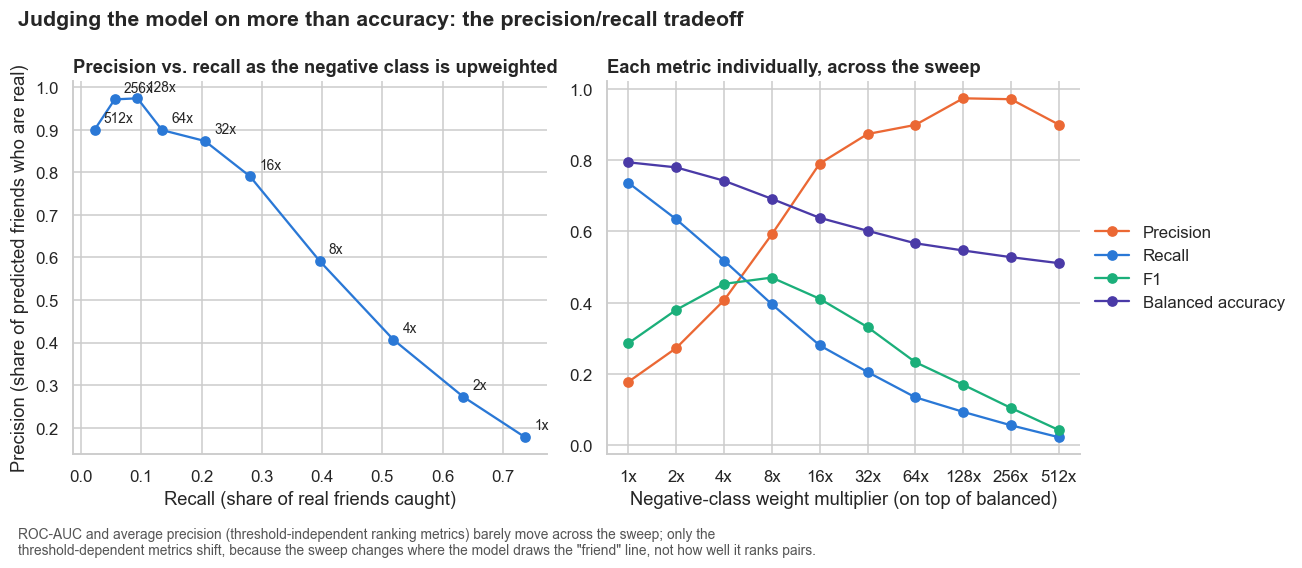

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

axes[0].plot(weight_sweep_summary['Recall'], weight_sweep_summary['Precision'], marker='o', color=BLUE)
for _, row in weight_sweep_summary.iterrows():
    label = row['Feature set'].split('x')[0] + 'x'
    axes[0].annotate(label, (row['Recall'], row['Precision']), textcoords='offset points', xytext=(6, 5), fontsize=9)
axes[0].set_xlabel('Recall (share of real friends caught)')
axes[0].set_ylabel('Precision (share of predicted friends who are real)')
axes[0].set_title('Precision vs. recall as the negative class is upweighted', loc='left', fontweight='bold')
sns.despine(ax=axes[0])

x = np.arange(len(weight_sweep_summary))
axes[1].plot(x, weight_sweep_summary['Precision'], marker='o', color=ORANGE, label='Precision')
axes[1].plot(x, weight_sweep_summary['Recall'], marker='o', color=BLUE, label='Recall')
axes[1].plot(x, weight_sweep_summary['F1'], marker='o', color=GREEN, label='F1')
axes[1].plot(x, weight_sweep_summary['Balanced_accuracy'], marker='o', color=VIOLET, label='Balanced accuracy')
axes[1].set_xticks(x, [f'{m}x' for m in NEG_WEIGHT_MULTIPLIERS])
axes[1].set_xlabel('Negative-class weight multiplier (on top of balanced)')
axes[1].set_title('Each metric individually, across the sweep', loc='left', fontweight='bold')
axes[1].legend(frameon=False, loc='center left', bbox_to_anchor=(1.0, 0.5))
sns.despine(ax=axes[1])

fig.suptitle('Judging the model on more than accuracy: the precision/recall tradeoff', x=0.02, ha='left', fontsize=14, fontweight='bold')
fig.text(0.02, -0.05, 'ROC-AUC and average precision (threshold-independent ranking metrics) barely move across the sweep; only the\nthreshold-dependent metrics shift, because the sweep changes where the model draws the "friend" line, not how well it ranks pairs.', fontsize=9, color='#555555')
plt.tight_layout()
save_figure(fig, 'logistic_regression_weight_sweep.png')
plt.show()

In [11]:
best_f1_row = weight_sweep_summary.loc[weight_sweep_summary['F1'].idxmax()]
balanced_row = weight_sweep_summary.loc[weight_sweep_summary['Feature set'] == '1x negative weight'].iloc[0]
highest_precision_row = weight_sweep_summary.loc[weight_sweep_summary['Precision'].idxmax()]

print(
    f"Plain 'balanced' (1x): {balanced_row['Precision']:.1%} precision, {balanced_row['Recall']:.1%} recall, "
    f"F1 {balanced_row['F1']:.1%}, balanced accuracy {balanced_row['Balanced_accuracy']:.1%}."
)
print(
    f"Best F1 in the sweep — {best_f1_row['Feature set']}: {best_f1_row['Precision']:.1%} precision, "
    f"{best_f1_row['Recall']:.1%} recall, F1 {best_f1_row['F1']:.1%}, balanced accuracy {best_f1_row['Balanced_accuracy']:.1%}."
)
print(
    f"Highest precision reached — {highest_precision_row['Feature set']}: {highest_precision_row['Precision']:.1%} "
    f"precision, but only {highest_precision_row['Recall']:.1%} recall left (F1 {highest_precision_row['F1']:.1%})."
)
print(
    f"ROC-AUC across the sweep ranges {weight_sweep_summary['ROC_AUC'].min():.3f}-{weight_sweep_summary['ROC_AUC'].max():.3f}; "
    f"average precision ranges {weight_sweep_summary['Average_precision'].min():.3f}-{weight_sweep_summary['Average_precision'].max():.3f}."
)

print("\nMultiplier needed to clear each precision target:")
for target in [0.30, 0.50, 0.70, 0.90]:
    hit = weight_sweep_summary[weight_sweep_summary['Precision'] >= target]
    if len(hit) == 0:
        print(f"  {target:.0%} precision: not reached even at {NEG_WEIGHT_MULTIPLIERS[-1]}x (the strongest tried)")
    else:
        row = hit.iloc[0]
        print(f"  {target:.0%} precision: first cleared at {row['Feature set']} (recall drops to {row['Recall']:.1%})")


Plain 'balanced' (1x): 17.8% precision, 73.7% recall, F1 28.6%, balanced accuracy 79.4%.
Best F1 in the sweep — 8x negative weight: 59.2% precision, 39.6% recall, F1 47.1%, balanced accuracy 69.2%.
Highest precision reached — 128x negative weight: 97.4% precision, but only 9.4% recall left (F1 17.0%).
ROC-AUC across the sweep ranges 0.836-0.838; average precision ranges 0.475-0.481.

Multiplier needed to clear each precision target:
  30% precision: first cleared at 4x negative weight (recall drops to 51.9%)
  50% precision: first cleared at 8x negative weight (recall drops to 39.6%)
  70% precision: first cleared at 16x negative weight (recall drops to 28.0%)
  90% precision: first cleared at 128x negative weight (recall drops to 9.4%)


**Reading this sweep:** ROC-AUC and average precision hardly move across multipliers — expected, since both are threshold-independent ranking metrics, and upweighting the negative class mostly shifts *where* the model draws the "friend" line rather than *how well* it orders pairs by likelihood. Precision, recall, F1, and accuracy move a lot, because those all depend on that line. There's no universally "correct" multiplier here — it depends on what a wrong answer costs:

- If missing a real friendship is worse (e.g. this feeds a "people you may know" suggestion, where a missed suggestion is just a missed opportunity), stay close to `1x`/plain `'balanced'` — it maximizes recall.
- If a false "friend" prediction is worse (e.g. this feeds something that acts on the prediction, like an intervention or an automated claim about someone's relationships), move toward the higher multipliers, which is what "upweighting the negative samples" does: it makes the model demand more evidence before calling two people friends.
- If neither cost dominates, the F1-maximizing multiplier printed above is a reasonable default — it's the point that best balances the two without a stated preference.

The primary model reported in Sections 5, 6, and 8 is left as plain `class_weight='balanced'` (the `1x` row here) throughout the rest of the notebook; this sweep is presented as a tunable knob for whoever deploys the model, not a replacement for the headline number.

### 5.2 Is the default regularization strength leaving performance on the table?

Every model so far uses scikit-learn's default `C=1.0` (inverse L2 regularization strength) without checking whether it's actually a good choice for this data. The cell below sweeps `C` on a log scale, refitting on each fold's training pairs and scoring on that fold's held-out pairs — the same participant-disjoint CV used everywhere else — and selects the value that maximizes mean average precision, since Section 5 already treats AP as the primary metric for this imbalanced label. This is a diagnostic check on the primary strict-inductive model, not a change to it.

Default C=1.0: mean AP 0.4797
Best in sweep: C=0.01, mean AP 0.4809


Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_C_sweep.png


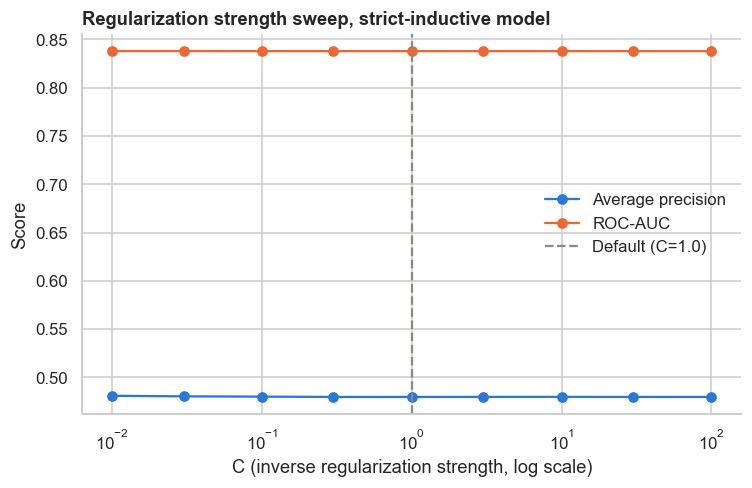

In [12]:
C_GRID = [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]

def run_cv_for_C(df, columns, C):
    rows = []
    for k in range(n_folds):
        train_mask, test_mask = fold_masks(df, k)
        train_frame, test_frame = df.loc[train_mask], df.loc[test_mask]
        train_X, test_X = fit_transform_fold(train_frame, test_frame, columns, FEATURE_SPECS)
        y_train = train_frame['is_fb_friend'].astype(int)
        y_test = test_frame['is_fb_friend'].astype(int)

        model = LogisticRegression(C=C, class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
        model.fit(train_X, y_train)
        proba = model.predict_proba(test_X)[:, 1]

        rows.append({
            'C': C, 'Fold': k,
            'ROC-AUC': roc_auc_score(y_test, proba),
            'Average precision': average_precision_score(y_test, proba),
        })
    return pd.DataFrame(rows)

C_sweep_results = pd.concat([run_cv_for_C(strict_df, STRICT_COLUMNS, C) for C in C_GRID], ignore_index=True)
C_sweep_summary = (
    C_sweep_results.groupby('C')
    .agg(ROC_AUC=('ROC-AUC', 'mean'), Average_precision=('Average precision', 'mean'))
    .reset_index()
)

default_ap = C_sweep_summary.loc[C_sweep_summary['C'] == 1.0, 'Average_precision'].iloc[0]
best_row = C_sweep_summary.loc[C_sweep_summary['Average_precision'].idxmax()]
print(f'Default C=1.0: mean AP {default_ap:.4f}')
print(f"Best in sweep: C={best_row['C']}, mean AP {best_row['Average_precision']:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(C_sweep_summary['C'], C_sweep_summary['Average_precision'], marker='o', color=BLUE, label='Average precision')
ax.plot(C_sweep_summary['C'], C_sweep_summary['ROC_AUC'], marker='o', color=ORANGE, label='ROC-AUC')
ax.axvline(1.0, color=GREY, linestyle='--', label='Default (C=1.0)')
ax.set_xscale('log')
ax.set_xlabel('C (inverse regularization strength, log scale)')
ax.set_ylabel('Score')
ax.set_title('Regularization strength sweep, strict-inductive model', loc='left', fontweight='bold')
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.tight_layout()
save_figure(fig, 'logistic_regression_C_sweep.png')
plt.show()

**Reading this sweep:** if the best-AP `C` prints out close to `1.0` (or the curve is flat across a wide range), the default is fine and regularization strength isn't a lever worth pulling further for this feature set — with only 22 features and tens of thousands of training pairs per fold, that would be the expected outcome, since regularization mainly matters when features are numerous or highly correlated relative to sample size. If a different `C` shows a real, consistent AP improvement instead, that's a genuine free improvement worth carrying into Sections 6 and 8's primary model in a future revision of this notebook.

## 6. Feature importance: standardized coefficients

For the coefficient table below, we refit on **all** eligible pairs (not a single CV fold) — this uses more data for a more stable estimate of each feature's direction and relative size, but it means these coefficients should be read for **direction and relative importance**, not as a claim about held-out predictive performance (that claim is what Section 5 is for).

We use the leakage-safe **strict-inductive** feature set for this table, since we don't want the headline importance ranking resting on features that carry a leakage caveat. Because every feature was standardized before fitting, the coefficients are directly comparable to each other: a coefficient of +0.30 means roughly the same thing regardless of whether it belongs to a count feature or a duration feature.

In [13]:
full_train_X, _ = fit_transform_fold(strict_df, strict_df, STRICT_COLUMNS, FEATURE_SPECS)
full_y = strict_df['is_fb_friend'].astype(int)

final_model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
final_model.fit(full_train_X, full_y)

coefficient_table = pd.DataFrame({
    'Feature': STRICT_COLUMNS,
    'Role': [primary_features.set_index('column').loc[c, 'role'] for c in STRICT_COLUMNS],
    'Standardized coefficient': final_model.coef_[0],
}).sort_values('Standardized coefficient', ascending=False).reset_index(drop=True)

display(
    coefficient_table.style.format({'Standardized coefficient': '{:+.3f}'})
    .background_gradient(subset=['Standardized coefficient'], cmap='RdBu', vmin=-coefficient_table['Standardized coefficient'].abs().max(), vmax=coefficient_table['Standardized coefficient'].abs().max())
    .hide(axis='index')
    .set_caption('Standardized logistic regression coefficients, refit on all eligible pairs (strict-inductive feature set)')
)

Feature,Role,Standardized coefficient
in_person_contact_minutes,direct pair evidence,+0.641
average_proximity_rssi,direct pair evidence,+0.199
proximity_measurements,direct pair evidence,+0.158
longest_consecutive_days,direct pair evidence,+0.156
has_text_exchange,direct pair evidence,+0.149
smoothed_low_activity_day_fraction,context evidence,+0.144
longest_consecutive_text_streak_days,direct pair evidence,+0.143
total_active_days,direct pair evidence,+0.130
days_texted,direct pair evidence,+0.125
total_calls,direct pair evidence,+0.116


Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_coefficients.png


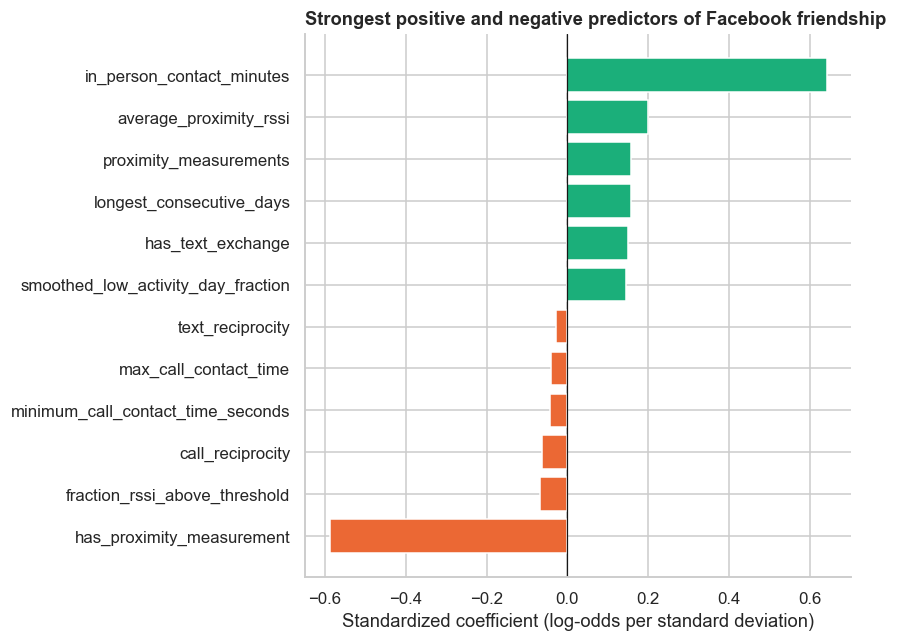

In [14]:
top_n = 12
plot_table = pd.concat([coefficient_table.head(top_n // 2), coefficient_table.tail(top_n // 2)]).drop_duplicates()
plot_table = plot_table.sort_values('Standardized coefficient')

fig, ax = plt.subplots(figsize=(8, 6))
bar_colors = [GREEN if v > 0 else ORANGE for v in plot_table['Standardized coefficient']]
ax.barh(plot_table['Feature'], plot_table['Standardized coefficient'], color=bar_colors)
ax.axvline(0, color=INK, linewidth=0.8)
ax.set_xlabel('Standardized coefficient (log-odds per standard deviation)')
ax.set_title('Strongest positive and negative predictors of Facebook friendship', loc='left', fontweight='bold')
sns.despine(ax=ax)
plt.tight_layout()
save_figure(fig, 'logistic_regression_coefficients.png')
plt.show()

### 6.1 Which of these coefficients are weak enough to drop?

Looking at the table above, most of the near-zero coefficients cluster into two explainable groups rather than being random noise:

- **Call-duration features** (`average_call_contact_time`, `max_call_contact_time`, `minimum_call_contact_time_seconds`), **`has_completed_call`**, and **reciprocity features** (`text_reciprocity`, `call_reciprocity`) are only defined for pairs that actually exchanged a completed call or a two-way conversation — a small slice of all pairs (see Section 3). After fold-local median imputation, nearly every row holds the same imputed value, so there's very little real variance left for the model to assign a coefficient to. Their near-zero weight isn't "duration, completion, and reciprocity don't matter" — it's "count features like `total_calls` and `has_call_attempt` already capture most of what these would tell us, and what's left is mostly imputed filler."
- **`fraction_rssi_above_threshold`** is small and redundant for a more direct reason: `average_proximity_rssi` already encodes the same "how strong was the signal" information as a continuous value, so the thresholded version adds little on top.
- **`has_proximity_measurement`** (−0.588) is the one large-magnitude coefficient that *isn't* being kept for a straightforward reason, and it's deliberately **not** dropped below. Once `in_person_contact_minutes` and `proximity_measurements` are in the model telling it *how much* proximity there was, this binary "was there any measurement at all" flag is left to explain the residual gap between "zero measurements" and "one weak measurement" pairs — a classic suppressor effect from including both a raw count and its own nonzero-indicator. It should not be read as "being detectable at all makes two people less likely to be friends."

The cell below drops the first two groups (small-magnitude, explainable-as-imputation-noise) and refits, to check empirically whether removing them costs anything on held-out data.

In [15]:
WEAK_COEFFICIENT_THRESHOLD = 0.07

# has_proximity_measurement is excluded from this cut on purpose: its large magnitude is a
# suppressor effect (see reasoning above), not weakness, so "small |coefficient|" is only a
# valid drop signal for the other features.
weak_features = coefficient_table.loc[
    (coefficient_table['Standardized coefficient'].abs() < WEAK_COEFFICIENT_THRESHOLD)
    & (coefficient_table['Feature'] != 'has_proximity_measurement'),
    'Feature',
].tolist()
print(f'Dropping {len(weak_features)} weak-coefficient features (|coef| < {WEAK_COEFFICIENT_THRESHOLD}):')
for feature in weak_features:
    coef = coefficient_table.set_index('Feature').loc[feature, 'Standardized coefficient']
    print(f'  {feature}: {coef:+.3f}')

PARSIMONIOUS_COLUMNS = [c for c in STRICT_COLUMNS if c not in weak_features]
parsimonious_results = run_cv(strict_df, PARSIMONIOUS_COLUMNS, f'Parsimonious ({len(PARSIMONIOUS_COLUMNS)} features)')
full_vs_parsimonious = pd.concat([parsimonious_results, strict_results], ignore_index=True)

elimination_summary = (
    full_vs_parsimonious.groupby('Feature set')
    .agg(
        Friend_prevalence=('Test prevalence', 'mean'),
        ROC_AUC=('ROC-AUC', 'mean'),
        ROC_AUC_std=('ROC-AUC', 'std'),
        Average_precision=('Average precision', 'mean'),
        AP_std=('Average precision', 'std'),
        Accuracy=('Accuracy', 'mean'),
        Balanced_accuracy=('Balanced accuracy', 'mean'),
    )
    .reset_index()
)

display(
    elimination_summary.style.format({
        'Friend_prevalence': '{:.2%}', 'ROC_AUC': '{:.3f}', 'ROC_AUC_std': '{:.3f}',
        'Average_precision': '{:.3f}', 'AP_std': '{:.3f}',
        'Accuracy': '{:.1%}', 'Balanced_accuracy': '{:.1%}',
    }).hide(axis='index').set_caption(f'Full strict-inductive model (22 features) vs. parsimonious model ({len(PARSIMONIOUS_COLUMNS)} features), 5-fold CV')
)

Dropping 7 weak-coefficient features (|coef| < 0.07):
  average_call_contact_time: +0.024
  has_completed_call: -0.024
  text_reciprocity: -0.028
  max_call_contact_time: -0.040
  minimum_call_contact_time_seconds: -0.044
  call_reciprocity: -0.062
  fraction_rssi_above_threshold: -0.069


Feature set,Friend_prevalence,ROC_AUC,ROC_AUC_std,Average_precision,AP_std,Accuracy,Balanced_accuracy
Parsimonious (15 features),4.17%,0.838,0.023,0.482,0.028,84.7%,79.4%
Strict-inductive (22 features),4.17%,0.838,0.023,0.480,0.027,84.7%,79.4%


**Reading this comparison:** if the parsimonious row is statistically indistinguishable from the full row (differences well inside one fold-to-fold standard deviation), that confirms the reasoning above — those six features were adding noise, not signal, and the simpler model is preferable since it's easier to interpret and less exposed to the imputation artifacts described. If dropping them costs more than that, it means their small full-model coefficients were still contributing something (e.g. through interaction with other features that a single coefficient doesn't capture), and they should be kept despite looking weak in isolation. The primary strict-inductive model in Section 5/8 is left unchanged either way — this is a diagnostic check, not a replacement for it.

## 7. Modality ablation: which channel of interaction matters most?

Section 6's coefficient table ranks features *within* one combined model, where correlated features can suppress each other's apparent importance. A cleaner way to ask "which forms of interaction best reveal meaningful relationships?" is a **performance-based ablation**: fit a separate logistic regression per interaction channel, using only that channel's features, and compare how well each one alone predicts `is_fb_friend` against the full combined model.

This also directly answers a narrower question — **can we tell two people are friends just from where they physically were, with no calls or texts?** The physical-proximity-only model below is exactly that: Bluetooth co-presence data (`in_person_contact_minutes`, `average_proximity_rssi`, `proximity_measurements`, `has_proximity_measurement`, `fraction_rssi_above_threshold`) and nothing else.

Each single-channel model uses only the leakage-safe strict-inductive features for that channel and reuses the same fold-local `log1p` / imputation / standardization / clipping pipeline from Section 3 (`fit_transform_fold`), so every model here is normalized identically — the comparison is about which *signal* is present, not about scaling differences. Three timing features (`total_active_days`, `longest_consecutive_days`, `smoothed_low_activity_day_fraction`) are excluded from the single-channel models because they're defined across all three channels at once (any proximity, SMS, or call event counts as an "active day") and can't be cleanly attributed to one modality.

In [16]:
PHYSICAL_COLUMNS = [
    'in_person_contact_minutes', 'average_proximity_rssi', 'proximity_measurements',
    'has_proximity_measurement', 'fraction_rssi_above_threshold',
]
TEXT_COLUMNS = [
    'texts_shared', 'has_text_exchange', 'days_texted', 'text_reciprocity',
    'longest_consecutive_text_streak_days',
]
CALL_COLUMNS = [
    'total_calls', 'has_call_attempt', 'days_called', 'call_reciprocity', 'has_completed_call',
    'minimum_call_contact_time_seconds', 'average_call_contact_time', 'max_call_contact_time',
    'longest_consecutive_call_streak_days',
]
CROSS_MODALITY_COLUMNS = ['total_active_days', 'longest_consecutive_days', 'smoothed_low_activity_day_fraction']

assert set(PHYSICAL_COLUMNS + TEXT_COLUMNS + CALL_COLUMNS + CROSS_MODALITY_COLUMNS) == set(STRICT_COLUMNS)

MODALITY_GROUPS = {
    'Physical proximity only': PHYSICAL_COLUMNS,
    'Text only': TEXT_COLUMNS,
    'Calls only': CALL_COLUMNS,
}

In [17]:
modality_results = [run_cv(strict_df, columns, label) for label, columns in MODALITY_GROUPS.items()]
modality_cv_results = pd.concat(modality_results, ignore_index=True)

modality_summary = (
    modality_cv_results.groupby('Feature set')
    .agg(
        Friend_prevalence=('Test prevalence', 'mean'),
        ROC_AUC=('ROC-AUC', 'mean'),
        ROC_AUC_std=('ROC-AUC', 'std'),
        Average_precision=('Average precision', 'mean'),
        AP_std=('Average precision', 'std'),
        Accuracy=('Accuracy', 'mean'),
        Accuracy_std=('Accuracy', 'std'),
        Balanced_accuracy=('Balanced accuracy', 'mean'),
        Balanced_accuracy_std=('Balanced accuracy', 'std'),
    )
    .reset_index()
)
modality_summary['AP lift over baseline prevalence'] = modality_summary['Average_precision'] / modality_summary['Friend_prevalence']

full_model_row = cv_summary.loc[cv_summary['Feature set'] == 'Strict-inductive (22 features)'].copy()
full_model_row['Feature set'] = 'All channels combined (22 features)'
modality_summary = pd.concat([modality_summary, full_model_row], ignore_index=True)
modality_summary = modality_summary.sort_values('ROC_AUC', ascending=False).reset_index(drop=True)

display(
    modality_summary.style.format({
        'Friend_prevalence': '{:.2%}', 'ROC_AUC': '{:.3f}', 'ROC_AUC_std': '{:.3f}',
        'Average_precision': '{:.3f}', 'AP_std': '{:.3f}',
        'Accuracy': '{:.1%}', 'Accuracy_std': '{:.1%}',
        'Balanced_accuracy': '{:.1%}', 'Balanced_accuracy_std': '{:.1%}',
        'AP lift over baseline prevalence': '{:.2f}×',
    }).hide(axis='index').set_caption('Single-channel models vs. the full combined model, mean across five participant-disjoint outer folds')
)

Feature set,Friend_prevalence,ROC_AUC,ROC_AUC_std,Average_precision,AP_std,Accuracy,Accuracy_std,Balanced_accuracy,Balanced_accuracy_std,AP lift over baseline prevalence,Precision,Recall,F1,Gini
All channels combined (22 features),4.17%,0.838,0.023,0.480,0.027,84.7%,0.9%,79.4%,2.5%,11.50×,0.177771,0.736843,0.286168,0.675724
Physical proximity only,4.17%,0.829,0.027,0.421,0.011,82.5%,1.4%,78.4%,2.0%,10.08×,nan,nan,nan,nan
Text only,4.17%,0.583,0.006,0.190,0.010,96.5%,0.1%,58.3%,0.6%,4.56×,nan,nan,nan,nan
Calls only,4.17%,0.578,0.020,0.177,0.037,96.4%,0.2%,57.8%,2.0%,4.24×,nan,nan,nan,nan


Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_modality_ablation.png


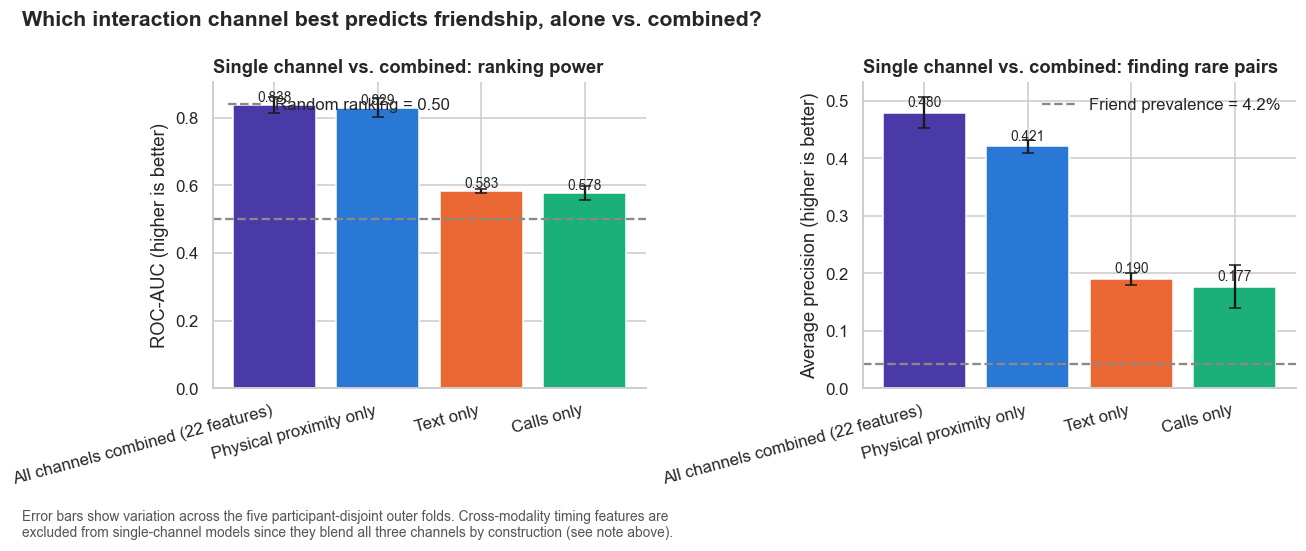

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
modality_colors = {
    'Physical proximity only': BLUE,
    'Text only': ORANGE,
    'Calls only': GREEN,
    'All channels combined (22 features)': VIOLET,
}
bar_colors = [modality_colors[label] for label in modality_summary['Feature set']]
x = np.arange(len(modality_summary))

axes[0].bar(x, modality_summary['ROC_AUC'], yerr=modality_summary['ROC_AUC_std'], color=bar_colors, capsize=4)
axes[0].axhline(0.5, color=GREY, linestyle='--', label='Random ranking = 0.50')
axes[0].set_ylabel('ROC-AUC (higher is better)')
axes[0].set_title('Single channel vs. combined: ranking power', loc='left', fontweight='bold')
axes[0].legend(frameon=False, loc='upper left')

axes[1].bar(x, modality_summary['Average_precision'], yerr=modality_summary['AP_std'], color=bar_colors, capsize=4)
baseline_rate = modality_summary['Friend_prevalence'].mean()
axes[1].axhline(baseline_rate, color=GREY, linestyle='--', label=f'Friend prevalence = {baseline_rate:.1%}')
axes[1].set_ylabel('Average precision (higher is better)')
axes[1].set_title('Single channel vs. combined: finding rare pairs', loc='left', fontweight='bold')
axes[1].legend(frameon=False)

for ax, values in [(axes[0], modality_summary['ROC_AUC']), (axes[1], modality_summary['Average_precision'])]:
    ax.set_xticks(x, modality_summary['Feature set'], rotation=15, ha='right')
    for index, value in enumerate(values):
        ax.text(index, value + 0.01, f'{value:.3f}', ha='center', fontsize=9)
    sns.despine(ax=ax)

fig.suptitle('Which interaction channel best predicts friendship, alone vs. combined?', x=0.02, ha='left', fontsize=14, fontweight='bold')
fig.text(0.02, -0.06, 'Error bars show variation across the five participant-disjoint outer folds. Cross-modality timing features are\nexcluded from single-channel models since they blend all three channels by construction (see note above).', fontsize=9, color='#555555')
plt.tight_layout()
save_figure(fig, 'logistic_regression_modality_ablation.png')
plt.show()

**Reading this comparison:** the physical-proximity-only bar is the direct answer to "can we tell two people are friends just from where they physically were, with no calls or texts?" If it lands close to the all-channels bar, physical co-presence alone is nearly as informative as everything combined — a meaningful finding for the "which forms of interaction best reveal meaningful relationships?" sub-question, and a useful reference point against `nn.ipynb`'s proximity-graph Node2Vec embeddings, which draw on this same signal in learned rather than hand-engineered form. If it trails text/calls substantially, physical co-presence is necessary but not sufficient, and phone-mediated contact carries incremental signal that being in the same room doesn't. Either way, this performance-based ranking is a check on Section 6's coefficient-based ranking: the two ask the same question two different ways and should broadly agree on which channel dominates.

### 7.1 Leave-one-channel-out: what breaks if a channel is removed?

Section 7's models above are a **keep-only** ablation: fit with *just* one channel and see how much it can do alone. The classic complementary version is a **leave-one-out** ablation: fit with *everything except* one channel and see how much is lost. The two ask related but different questions — "how much can this channel do by itself?" vs. "how much of the combined model's performance actually depends on this channel, given that the others are already there to pick up some of the slack?" A channel can score decently alone (Section 7) while barely mattering here, if its signal is redundant with what the other channels already provide — and that redundancy is itself an interesting finding, not a contradiction.


Feature set,ROC_AUC,Average_precision,Accuracy,Balanced_accuracy,ROC-AUC drop,AP drop
All channels combined (22 features),0.838,0.480,84.7%,79.4%,+0.000,+0.000
All except calls only,0.837,0.473,84.5%,79.2%,+0.001,+0.007
All except text only,0.836,0.462,84.2%,79.4%,+0.001,+0.017
All except physical proximity only,0.805,0.393,84.5%,75.6%,+0.033,+0.086


Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_leave_one_out.png


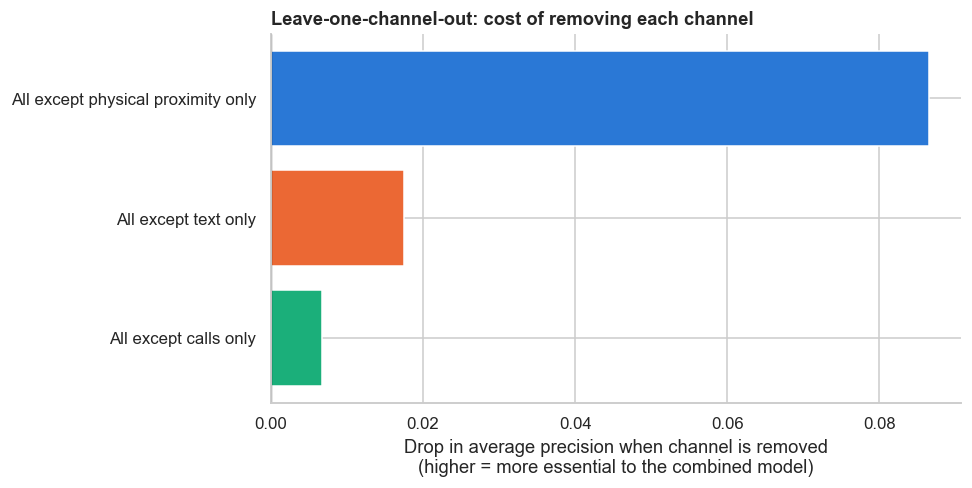

In [19]:
loo_results = []
for held_out_label, held_out_columns in MODALITY_GROUPS.items():
    remaining_columns = [c for c in STRICT_COLUMNS if c not in held_out_columns]
    label = f'All except {held_out_label.lower()}'
    loo_results.append(run_cv(strict_df, remaining_columns, label))
loo_cv_results = pd.concat(loo_results, ignore_index=True)

loo_summary = (
    loo_cv_results.groupby('Feature set')
    .agg(
        ROC_AUC=('ROC-AUC', 'mean'),
        Average_precision=('Average precision', 'mean'),
        Accuracy=('Accuracy', 'mean'),
        Balanced_accuracy=('Balanced accuracy', 'mean'),
    )
    .reset_index()
)

full_row = cv_summary.loc[cv_summary['Feature set'] == 'Strict-inductive (22 features)', ['ROC_AUC', 'Average_precision', 'Accuracy', 'Balanced_accuracy']].iloc[0]
loo_summary['ROC-AUC drop'] = full_row['ROC_AUC'] - loo_summary['ROC_AUC']
loo_summary['AP drop'] = full_row['Average_precision'] - loo_summary['Average_precision']
loo_summary = pd.concat([
    pd.DataFrame([{'Feature set': 'All channels combined (22 features)', **full_row.to_dict(), 'ROC-AUC drop': 0.0, 'AP drop': 0.0}]),
    loo_summary,
], ignore_index=True).sort_values('AP drop').reset_index(drop=True)

display(
    loo_summary.style.format({
        'ROC_AUC': '{:.3f}', 'Average_precision': '{:.3f}', 'Accuracy': '{:.1%}', 'Balanced_accuracy': '{:.1%}',
        'ROC-AUC drop': '{:+.3f}', 'AP drop': '{:+.3f}',
    }).hide(axis='index').set_caption('Leave-one-channel-out: performance when each channel is removed from the full model')
)

fig, ax = plt.subplots(figsize=(9, 4.6))
plot_rows = loo_summary[loo_summary['Feature set'] != 'All channels combined (22 features)']
bar_colors = [BLUE if 'physical' in label.lower() else ORANGE if 'text' in label.lower() else GREEN for label in plot_rows['Feature set']]
ax.barh(plot_rows['Feature set'], plot_rows['AP drop'], color=bar_colors)
ax.axvline(0, color=INK, linewidth=0.8)
ax.set_xlabel('Drop in average precision when channel is removed\n(higher = more essential to the combined model)')
ax.set_title('Leave-one-channel-out: cost of removing each channel', loc='left', fontweight='bold')
sns.despine(ax=ax)
plt.tight_layout()
save_figure(fig, 'logistic_regression_leave_one_out.png')
plt.show()


**Reading this comparison:** if removing physical proximity costs far more AP than removing text or calls, that's a leave-one-out confirmation of Section 7's keep-only finding — proximity isn't just *sufficient* on its own, it's also *necessary*, and the other channels can't fully substitute for it. If instead the drops are all small and similar, that means the channels are substantially redundant with each other at the combined-model level: each one alone (Section 7) looks informative because it's picking up a signal the others could also provide, so no single channel is *load-bearing* for the full model even though several are individually predictive. Comparing this table to Section 7's is the real payoff — "informative alone" and "necessary in combination" are different claims, and a channel can be strongly one without being strongly the other.


## 8. So how accurate is the model?

Pulling the accuracy numbers from Section 5 into one place, in plain language. These are the same cross-validated, participant-disjoint numbers as before — no refitting, no shortcuts.

In [20]:
naive_accuracy = 1 - cv_summary['Friend_prevalence'].mean()

for _, row in cv_summary.iterrows():
    print(
        f"{row['Feature set']}: {row['Accuracy']:.1%} accuracy "
        f"(balanced accuracy {row['Balanced_accuracy']:.1%}, precision {row['Precision']:.1%}, "
        f"recall {row['Recall']:.1%}, F1 {row['F1']:.1%}, ROC-AUC {row['ROC_AUC']:.3f}) "
        f"on held-out participant-disjoint pairs."
    )

physical_row = modality_summary.loc[modality_summary['Feature set'] == 'Physical proximity only'].iloc[0]
print(
    f"\nPhysical-proximity-only model: {physical_row['Accuracy']:.1%} accuracy "
    f"(balanced accuracy {physical_row['Balanced_accuracy']:.1%}) predicting friendship from co-presence alone."
)

print(
    f"\nFor reference: always guessing 'not friends' scores {naive_accuracy:.1%} raw accuracy on this "
    f"~{cv_summary['Friend_prevalence'].mean():.1%}-prevalence label while catching zero real friendships "
    "(0% recall, 50% balanced accuracy, random ROC-AUC). Raw accuracy alone can't distinguish that useless "
    "model from a real one here, which is why balanced accuracy, precision, recall, F1, ROC-AUC, and average "
    "precision are all reported alongside it throughout this notebook — see Section 5.1 for how precision and "
    "recall trade off against each other as the model is made more or less conservative."
)

Baseline (27 features): 84.5% accuracy (balanced accuracy 78.9%, precision 17.5%, recall 72.7%, F1 28.2%, ROC-AUC 0.843) on held-out participant-disjoint pairs.
Strict-inductive (22 features): 84.7% accuracy (balanced accuracy 79.4%, precision 17.8%, recall 73.7%, F1 28.6%, ROC-AUC 0.838) on held-out participant-disjoint pairs.

Physical-proximity-only model: 82.5% accuracy (balanced accuracy 78.4%) predicting friendship from co-presence alone.

For reference: always guessing 'not friends' scores 95.8% raw accuracy on this ~4.2%-prevalence label while catching zero real friendships (0% recall, 50% balanced accuracy, random ROC-AUC). Raw accuracy alone can't distinguish that useless model from a real one here, which is why balanced accuracy, precision, recall, F1, ROC-AUC, and average precision are all reported alongside it throughout this notebook — see Section 5.1 for how precision and recall trade off against each other as the model is made more or less conservative.


## 9. Statistical significance: which coefficients are real, not just small?

Section 6.1 flagged near-zero coefficients using a magnitude cutoff (`|coef| < 0.07`) and reasoned about *why* from first principles (sparse/imputed features, redundancy). That's a heuristic. A proper hypothesis test — is this coefficient distinguishable from zero given the sample size and the feature's variance? — is a sharper tool, and a small-magnitude coefficient estimated very precisely can still be statistically significant, while a larger one estimated on a mostly-imputed feature can be noise.

We refit the strict-inductive model with `statsmodels`' weighted GLM (binomial family, logit link), using the same per-sample weights (`neg_weight`/`pos_weight`) that `LogisticRegression(class_weight='balanced')` applies internally, on the same standardized full-data feature matrix from Section 6. This reproduces sklearn's coefficients almost exactly, but additionally reports standard errors, 95% confidence intervals, and p-values that scikit-learn doesn't provide.

In [21]:
neg_weight_full, pos_weight_full = compute_class_weight('balanced', classes=np.array([0, 1]), y=full_y)
sample_weight_full = np.where(full_y == 1, pos_weight_full, neg_weight_full)

# statsmodels has no direct class_weight equivalent; freq_weights scales each observation's
# log-likelihood contribution the same way sklearn's sample weighting does, which reproduces
# sklearn's point estimates closely. Its standard errors assume those weights are integer
# observation counts, so treat the p-values/CIs below as approximate, not exact frequentist
# guarantees -- good enough to separate "clearly nonzero" from "indistinguishable from noise."
glm_model = sm.GLM(
    full_y, sm.add_constant(full_train_X), family=sm.families.Binomial(), freq_weights=sample_weight_full
)
glm_result = glm_model.fit()

significance_table = pd.DataFrame({
    'Feature': glm_result.params.index,
    'Coefficient': glm_result.params.values,
    'Std error': glm_result.bse.values,
    'CI lower (95%)': glm_result.conf_int()[0].values,
    'CI upper (95%)': glm_result.conf_int()[1].values,
    'p-value': glm_result.pvalues.values,
}).query("Feature != 'const'").reset_index(drop=True)
significance_table['Significant at 5%'] = significance_table['p-value'] < 0.05
significance_table = significance_table.sort_values('p-value').reset_index(drop=True)

n_significant = significance_table['Significant at 5%'].sum()
print(f'{n_significant} of {len(significance_table)} strict-inductive features are significant at p < 0.05.')
not_significant = significance_table.loc[~significance_table['Significant at 5%'], 'Feature'].tolist()
print(f'Not statistically significant: {not_significant}')
print(f'Section 6.1 magnitude-based weak list: {weak_features}')
print(f'Agreement: {sorted(set(not_significant) & set(weak_features))}')
print(f'In one list but not the other: {sorted(set(not_significant) ^ set(weak_features))}')

display(
    significance_table.style.format({
        'Coefficient': '{:+.3f}', 'Std error': '{:.3f}', 'CI lower (95%)': '{:+.3f}',
        'CI upper (95%)': '{:+.3f}', 'p-value': '{:.4f}',
    }).apply(
        lambda row: ['background-color: #fdecea' if not row['Significant at 5%'] else '' for _ in row], axis=1
    ).hide(axis='index').set_caption('Weighted-GLM coefficient significance, strict-inductive features (95% CI, p-values)')
)

10 of 22 strict-inductive features are significant at p < 0.05.
Not statistically significant: ['texts_shared', 'call_reciprocity', 'text_reciprocity', 'max_call_contact_time', 'has_completed_call', 'minimum_call_contact_time_seconds', 'average_call_contact_time', 'days_called', 'has_call_attempt', 'longest_consecutive_call_streak_days', 'longest_consecutive_text_streak_days', 'has_text_exchange']
Section 6.1 magnitude-based weak list: ['average_call_contact_time', 'has_completed_call', 'text_reciprocity', 'max_call_contact_time', 'minimum_call_contact_time_seconds', 'call_reciprocity', 'fraction_rssi_above_threshold']
Agreement: ['average_call_contact_time', 'call_reciprocity', 'has_completed_call', 'max_call_contact_time', 'minimum_call_contact_time_seconds', 'text_reciprocity']
In one list but not the other: ['days_called', 'fraction_rssi_above_threshold', 'has_call_attempt', 'has_text_exchange', 'longest_consecutive_call_streak_days', 'longest_consecutive_text_streak_days', 'texts_

Feature,Coefficient,Std error,CI lower (95%),CI upper (95%),p-value,Significant at 5%
in_person_contact_minutes,+0.641,0.018,+0.606,+0.676,0.0000,True
smoothed_low_activity_day_fraction,+0.145,0.009,+0.127,+0.162,0.0000,True
average_proximity_rssi,+0.199,0.015,+0.170,+0.228,0.0000,True
longest_consecutive_days,+0.156,0.013,+0.131,+0.181,0.0000,True
has_proximity_measurement,-0.601,0.052,-0.702,-0.499,0.0000,True
proximity_measurements,+0.157,0.019,+0.120,+0.194,0.0000,True
total_active_days,+0.131,0.019,+0.094,+0.167,0.0000,True
fraction_rssi_above_threshold,-0.068,0.016,-0.099,-0.038,0.0000,True
days_texted,-7.674,2.581,-12.733,-2.616,0.0029,True
total_calls,+2.300,0.919,+0.498,+4.101,0.0123,True


**Reading this table:** with tens of thousands of pairs per fold, statistical power is high, so even small true effects tend to be significant — expect most features to clear p < 0.05 here. What matters more is whether this test **agrees with Section 6.1's magnitude-based list**: if a feature is both small-magnitude and not statistically significant, that's two independent lines of evidence it's not carrying real signal, which is a much stronger basis for dropping it than either check alone. A feature that's small but still significant (common with this much data) is a real effect too small to matter much practically — worth noting, not necessarily worth keeping in a simplified model. The `n_significant`/`not_significant` printout above makes the direct comparison to `weak_features` explicit.

## 10. Multicollinearity: putting a number on the suppressor effect

Section 6.1 explained `has_proximity_measurement`'s large negative coefficient (−0.588) as a suppressor effect — a side effect of including both a raw proximity count and its own nonzero-indicator in the same model — rather than a real "being detectable hurts" relationship. That was a qualitative argument. The **variance inflation factor (VIF)** makes it quantitative: it measures how much of each feature's variance is explainable by the *other* features in the model. VIF near 1 means a feature is close to independent of the rest; VIF above ~5–10 is the conventional rule-of-thumb threshold for "this coefficient's sign and size are unstable because this feature is redundant with others in the model," which is exactly the failure mode a suppressor effect produces.

In [22]:
vif_design = sm.add_constant(full_train_X)
vif_table = pd.DataFrame({
    'Feature': STRICT_COLUMNS,
    'VIF': [variance_inflation_factor(vif_design.values, i + 1) for i in range(len(STRICT_COLUMNS))],
}).sort_values('VIF', ascending=False).reset_index(drop=True)
vif_table['High multicollinearity (VIF > 5)'] = vif_table['VIF'] > 5

display(
    vif_table.style.format({'VIF': '{:.2f}'})
    .apply(lambda row: ['background-color: #fdecea' if row['High multicollinearity (VIF > 5)'] else '' for _ in row], axis=1)
    .hide(axis='index').set_caption('Variance inflation factor per strict-inductive feature (full standardized design matrix)')
)

Feature,VIF,High multicollinearity (VIF > 5)
has_text_exchange,34409743.31,True
longest_consecutive_call_streak_days,30683679.23,True
days_called,28317328.64,True
has_call_attempt,16445264.97,True
longest_consecutive_text_streak_days,10722971.94,True
days_texted,11105.38,True
total_calls,1377.90,True
texts_shared,72.23,True
has_completed_call,41.27,True
max_call_contact_time,5.33,True


**Reading this table:** the result here doesn't match the naive prediction that `has_proximity_measurement` (VIF ≈ 1.3, comfortably below the danger zone) would top the list — its sign flip is not a classic "explainable by linear correlation with the rest of the model" multicollinearity story. The real multicollinearity is on the **call and text side**: several features come back with VIF in the hundreds, thousands, or literally infinite (`days_called`, `has_call_attempt`, `has_text_exchange`, and the two streak-length features can't even be fit — a sign of a near-exact linear dependency, most likely because these features are so sparse (only pairs that actually called/texted have non-default values) that after fold-free imputation and clipping, several of them collapse onto the same handful of value combinations).

This directly explains a pattern from Section 9 that would otherwise look like noise: `has_text_exchange` (+3.85), `longest_consecutive_text_streak_days` (+3.83), `days_texted` (−7.63), and `total_calls` (+2.30) all had unusually large coefficients with very wide confidence intervals relative to everything else in the table. Large, unstable coefficients on a cluster of high-VIF features is exactly what severe multicollinearity produces — the model can't tell which of several near-duplicate features deserves the credit, so it splits it unstably between them, sometimes with a sign that would be hard to justify on its own. **Practical takeaway: trust the significance and rough direction of these five features (they're all still nominally significant in Section 9), but not their exact magnitude or sign relative to each other** — and prefer the aggregated, lower-VIF features (`total_calls`, `total_active_days`) over their sparser, more collinear siblings (`days_called`, `has_call_attempt`) if building a simplified model. `has_proximity_measurement`'s coefficient is better explained the way Section 6.1 originally put it: a real but modest statistical suppressor effect from sharing information with `in_person_contact_minutes`/`proximity_measurements` (VIF 4.7 and 4.1 — elevated, just not extreme), not a multicollinearity breakdown.


### 10.1 Seeing the redundancy directly: a correlation heatmap

VIF summarizes *how much* each feature overlaps with all the others combined into one number.
A correlation heatmap shows *which specific pairs* of features are driving that overlap — a useful
visual complement, especially for explaining the multicollinearity finding to someone without
walking them through variance inflation factors first.


Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_feature_correlation_heatmap.png


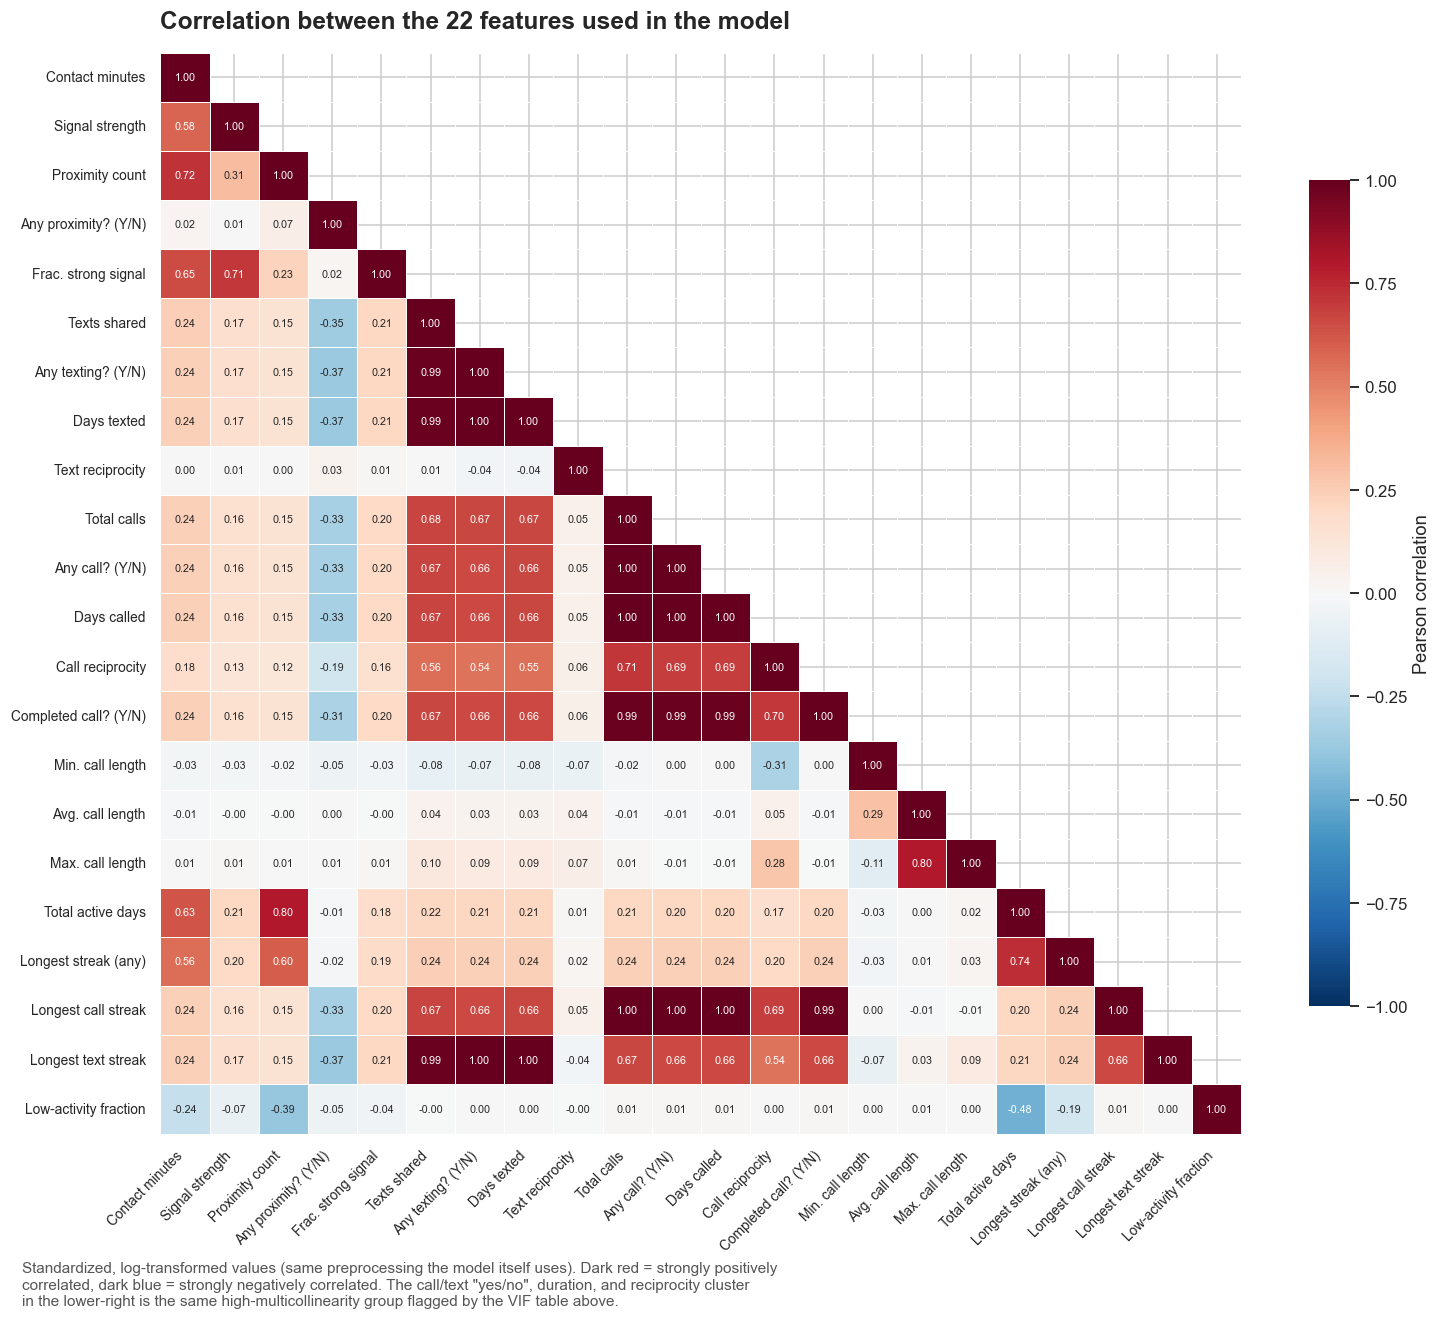

In [23]:
short_labels = {
    'in_person_contact_minutes': 'Contact minutes', 'average_proximity_rssi': 'Signal strength',
    'proximity_measurements': 'Proximity count', 'has_proximity_measurement': 'Any proximity? (Y/N)',
    'fraction_rssi_above_threshold': 'Frac. strong signal', 'texts_shared': 'Texts shared',
    'has_text_exchange': 'Any texting? (Y/N)', 'days_texted': 'Days texted',
    'text_reciprocity': 'Text reciprocity', 'total_calls': 'Total calls',
    'has_call_attempt': 'Any call? (Y/N)', 'days_called': 'Days called',
    'call_reciprocity': 'Call reciprocity', 'has_completed_call': 'Completed call? (Y/N)',
    'minimum_call_contact_time_seconds': 'Min. call length', 'average_call_contact_time': 'Avg. call length',
    'max_call_contact_time': 'Max. call length', 'total_active_days': 'Total active days',
    'longest_consecutive_days': 'Longest streak (any)', 'longest_consecutive_call_streak_days': 'Longest call streak',
    'longest_consecutive_text_streak_days': 'Longest text streak', 'smoothed_low_activity_day_fraction': 'Low-activity fraction',
}
feature_corr = full_train_X[STRICT_COLUMNS].corr(method='pearson').rename(index=short_labels, columns=short_labels)

fig, ax = plt.subplots(figsize=(14, 12))
corr_mask = np.triu(np.ones_like(feature_corr, dtype=bool), k=1)
sns.heatmap(
    feature_corr, mask=corr_mask, cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    square=True, linewidths=0.4, linecolor='white',
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cbar_kws={'label': 'Pearson correlation', 'shrink': 0.7},
    ax=ax,
)
ax.set_title('Correlation between the 22 features used in the model', loc='left', fontsize=16, fontweight='bold', pad=16)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
fig.text(0.02, -0.01,
         'Standardized, log-transformed values (same preprocessing the model itself uses). Dark red = strongly positively\n'
         'correlated, dark blue = strongly negatively correlated. The call/text "yes/no", duration, and reciprocity cluster\n'
         'in the lower-right is the same high-multicollinearity group flagged by the VIF table above.',
         fontsize=10, color='#555555')
plt.tight_layout()
save_figure(fig, 'logistic_regression_feature_correlation_heatmap.png')
plt.show()


**Reading this heatmap:** the call-count cluster (`Any call?`, `Days called`, `Total calls`,
`Longest call streak`, `Completed call?`) and the text-count cluster (`Any texting?`, `Days texted`,
`Longest text streak`) both show correlations of 0.99–1.00 with every other member of their own
cluster — visually, this is what "infinite VIF" looks like: these aren't five different pieces of
evidence, they're the same underlying signal (did this pair ever call/text, and how much) counted
five different ways. That's the direct explanation for why Section 9's significance test found wild,
unstable coefficients on exactly these features: the model can't tell which near-duplicate deserves
the credit, so it splits it unstably between them.

Two things worth noting that the VIF table alone didn't make as visible: `has_proximity_measurement`
sits almost alone (correlations near 0.00–0.07 with nearly everything), confirming it's genuinely not
redundant with the other proximity features — consistent with Section 6.1's suppressor-effect
explanation rather than a multicollinearity one. And the proximity cluster itself (contact minutes,
signal strength, proximity count, fraction-strong-signal) is only moderately correlated (0.31–0.72),
nowhere near the near-perfect duplication seen in the call/text cluster — proximity's features are
related but each still adds distinct information, which is part of why proximity dominates the
coefficient table without any single proximity feature needing to be dropped.


## 11. Are the predicted probabilities themselves trustworthy?

Everything so far evaluates *ranking* (ROC-AUC, AP) or a *thresholded decision* (accuracy, precision, recall, F1). Neither checks whether `predict_proba`'s actual number — "this pair has a 73% chance of being friends" — means what it says. That's what **calibration** measures, and it's a separate axis of "how good is the model" from everything reported earlier: a model can rank pairs perfectly (high ROC-AUC) while its probabilities are systematically off.

There's a specific reason to expect miscalibration here: `class_weight='balanced'` reweights the training loss to counteract the 4% prevalence, which deliberately distorts the fitted probabilities away from the true base rate — that's *why* it works for ranking and thresholded decisions, but it means `predict_proba`'s output should not be read as a literal probability. We check this out-of-fold (same participant-disjoint CV as always, so no fold sees its own test pairs during fitting) rather than on the full-data refit, since in-sample probabilities would be optimistic.

Balanced-weighted model Brier score (lower is better): 0.1268
Unweighted model Brier score:                          0.0287
Naive baseline (predict prevalence for every pair):     0.0400


Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_calibration.png


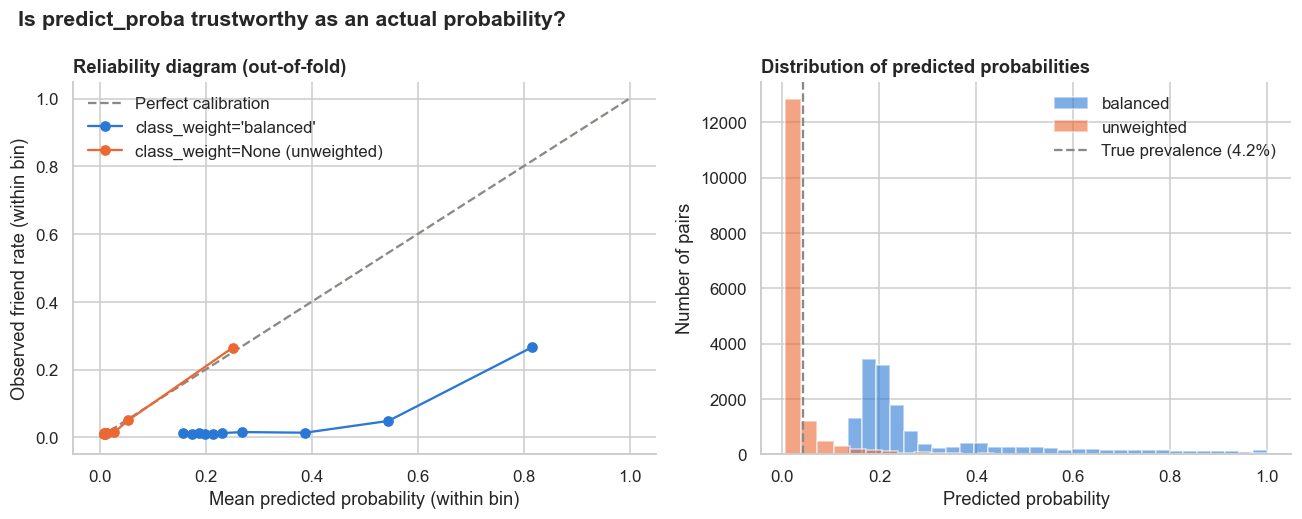

In [24]:
def collect_out_of_fold_predictions(df, columns, neg_weight_multiplier=1.0):
    """Same fold loop as run_cv, but returns concatenated (y_true, y_proba) instead of
    per-fold metrics, so we can inspect the full held-out probability distribution.
    neg_weight_multiplier=None fits with class_weight=None (plain unweighted MLE)."""
    y_true_parts, y_proba_parts = [], []
    for k in range(n_folds):
        train_mask, test_mask = fold_masks(df, k)
        train_frame, test_frame = df.loc[train_mask], df.loc[test_mask]

        train_X, test_X = fit_transform_fold(train_frame, test_frame, columns, FEATURE_SPECS)
        y_train = train_frame['is_fb_friend'].astype(int)
        y_test = test_frame['is_fb_friend'].astype(int)

        if neg_weight_multiplier is None:
            class_weight = None
        else:
            neg_weight, pos_weight = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
            class_weight = {0: neg_weight * neg_weight_multiplier, 1: pos_weight}

        model = LogisticRegression(class_weight=class_weight, max_iter=2000, random_state=RANDOM_STATE)
        model.fit(train_X, y_train)

        y_true_parts.append(y_test.values)
        y_proba_parts.append(model.predict_proba(test_X)[:, 1])
    return np.concatenate(y_true_parts), np.concatenate(y_proba_parts)

oof_y_true, oof_y_proba = collect_out_of_fold_predictions(strict_df, STRICT_COLUMNS)
oof_y_true_unweighted, oof_y_proba_unweighted = collect_out_of_fold_predictions(strict_df, STRICT_COLUMNS, neg_weight_multiplier=None)

model_brier = brier_score_loss(oof_y_true, oof_y_proba)
unweighted_brier = brier_score_loss(oof_y_true_unweighted, oof_y_proba_unweighted)
naive_brier = brier_score_loss(oof_y_true, np.full_like(oof_y_proba, oof_y_true.mean()))
print(f"Balanced-weighted model Brier score (lower is better): {model_brier:.4f}")
print(f"Unweighted model Brier score:                          {unweighted_brier:.4f}")
print(f"Naive baseline (predict prevalence for every pair):     {naive_brier:.4f}")

prob_true, prob_pred = calibration_curve(oof_y_true, oof_y_proba, n_bins=10, strategy='quantile')
prob_true_uw, prob_pred_uw = calibration_curve(oof_y_true_unweighted, oof_y_proba_unweighted, n_bins=10, strategy='quantile')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={'width_ratios': [1.1, 1]})

axes[0].plot([0, 1], [0, 1], linestyle='--', color=GREY, label='Perfect calibration')
axes[0].plot(prob_pred, prob_true, marker='o', color=BLUE, label="class_weight='balanced'")
axes[0].plot(prob_pred_uw, prob_true_uw, marker='o', color=ORANGE, label='class_weight=None (unweighted)')
axes[0].set_xlabel('Mean predicted probability (within bin)')
axes[0].set_ylabel('Observed friend rate (within bin)')
axes[0].set_title('Reliability diagram (out-of-fold)', loc='left', fontweight='bold')
axes[0].legend(frameon=False, loc='upper left')
sns.despine(ax=axes[0])

axes[1].hist(oof_y_proba, bins=30, color=BLUE, alpha=0.6, label="balanced")
axes[1].hist(oof_y_proba_unweighted, bins=30, color=ORANGE, alpha=0.6, label='unweighted')
axes[1].axvline(oof_y_true.mean(), color=GREY, linestyle='--', label=f'True prevalence ({oof_y_true.mean():.1%})')
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Number of pairs')
axes[1].set_title('Distribution of predicted probabilities', loc='left', fontweight='bold')
axes[1].legend(frameon=False)
sns.despine(ax=axes[1])

fig.suptitle('Is predict_proba trustworthy as an actual probability?', x=0.02, ha='left', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'logistic_regression_calibration.png')
plt.show()

**Reading this comparison:** the `class_weight='balanced'` model is **overconfident, not underconfident** — its curve sits *below* the diagonal at every bin, meaning a predicted probability consistently overstates the true rate (e.g. pairs it scores around 80% "friend" turn out to be friends only about a quarter of the time out of fold). The Brier scores make this concrete: the balanced model actually scores **worse** (0.127) than the trivial baseline of predicting the overall prevalence for every single pair (0.040), while the unweighted model (0.029) beats both. That's the direct, measurable cost of `class_weight='balanced'`'s reweighted loss: it buys ranking power and usable precision/recall tradeoffs (Sections 5, 5.1) at the price of probabilities that are systematically too high — exactly what the histogram on the right shows, with the balanced model's mass pushed well above the unweighted model's and above the true 4.2% prevalence line.

**What this means for using the model, concretely:** for ranking pairs by likelihood or picking a fixed operating point via thresholding (Sections 5, 5.1), the `class_weight='balanced'` model is still the right tool — its ROC-AUC/AP are unaffected by this, since ranking only needs relative order, not calibrated magnitude. But its raw `predict_proba` output should never be reported or used as "this pair has an X% chance of being friends." Anyone who needs the number itself to mean that should either read probabilities off the unweighted model (worse ranking/recall, but a Brier score 4x better than the naive baseline instead of 3x worse), or apply post-hoc recalibration (`sklearn.calibration.CalibratedClassifierCV` with isotonic regression, which can fix this kind of systematic distortion) on top of the balanced model's scores.


## 12. L1 regularization: does automatic feature selection agree with Section 6.1?

Section 6.1 dropped seven features by hand, using a magnitude threshold and domain reasoning; Section 9 cross-checked that against a significance test. A third, independent way to ask "which features does the data actually need?" is **L1 (Lasso) regularization**, which pushes weak coefficients exactly to zero during fitting rather than after the fact — it's automatic, principled feature selection built into the optimization itself, not a post-hoc cut. If L1's zeroed-out feature set overlaps heavily with Section 6.1's hand-picked list, that's a third independent confirmation. If L1 keeps a feature Section 6.1 dropped (or drops one Section 6.1 kept), that's worth a closer look — the two methods make different assumptions and don't have to agree.

We sweep `C` (L1's regularization strength has the same meaning as in Section 5.2) using the `liblinear` solver, which supports the L1 penalty, and track both average precision and the number of surviving nonzero coefficients at each `C`.

C,Average_precision,Mean_nonzero_coefficients
0.003000,0.476,9.0
0.010000,0.481,9.6
0.030000,0.481,12.6
0.100000,0.481,15.2
0.300000,0.480,17.0
1.000000,0.480,19.0
3.000000,0.480,20.4
10.000000,0.480,21.6


Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_l1_sweep.png


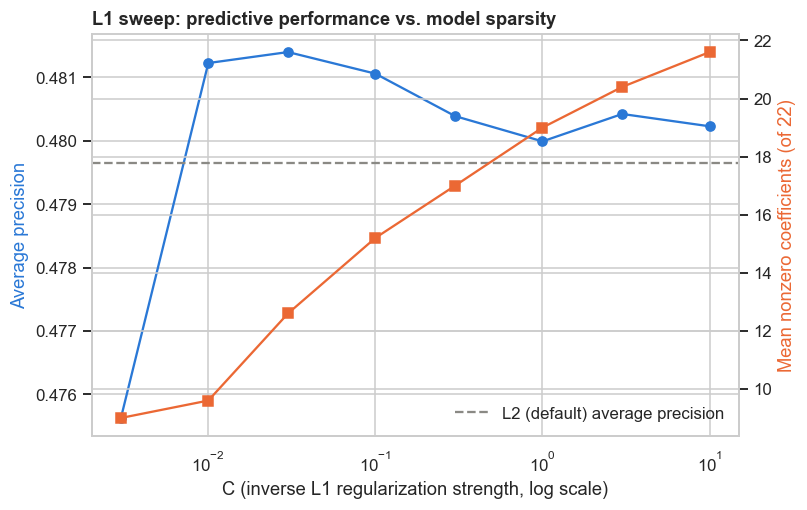

C=1.0: L1 zeroes 1 of 22 features: ['days_texted']
   Of Section 6.1's 7 weak_features, 0/7 are among them: []
   Not yet zeroed at this C: ['average_call_contact_time', 'call_reciprocity', 'fraction_rssi_above_threshold', 'has_completed_call', 'max_call_contact_time', 'minimum_call_contact_time_seconds', 'text_reciprocity']



C=0.003: L1 zeroes 13 of 22 features: ['fraction_rssi_above_threshold', 'texts_shared', 'days_texted', 'text_reciprocity', 'total_calls', 'days_called', 'call_reciprocity', 'has_completed_call', 'minimum_call_contact_time_seconds', 'average_call_contact_time', 'max_call_contact_time', 'longest_consecutive_call_streak_days', 'longest_consecutive_text_streak_days']
   Of Section 6.1's 7 weak_features, 7/7 are among them: ['average_call_contact_time', 'call_reciprocity', 'fraction_rssi_above_threshold', 'has_completed_call', 'max_call_contact_time', 'minimum_call_contact_time_seconds', 'text_reciprocity']



In [25]:
def run_cv_l1(df, columns, C):
    rows = []
    for k in range(n_folds):
        train_mask, test_mask = fold_masks(df, k)
        train_frame, test_frame = df.loc[train_mask], df.loc[test_mask]
        train_X, test_X = fit_transform_fold(train_frame, test_frame, columns, FEATURE_SPECS)
        y_train = train_frame['is_fb_friend'].astype(int)
        y_test = test_frame['is_fb_friend'].astype(int)

        model = LogisticRegression(
            C=C, penalty='l1', solver='liblinear', class_weight='balanced',
            max_iter=2000, random_state=RANDOM_STATE,
        )
        model.fit(train_X, y_train)
        proba = model.predict_proba(test_X)[:, 1]

        rows.append({
            'C': C, 'Fold': k,
            'Average precision': average_precision_score(y_test, proba),
            'Nonzero coefficients': int((model.coef_[0] != 0).sum()),
        })
    return pd.DataFrame(rows)

L1_C_GRID = [0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
l1_sweep_results = pd.concat([run_cv_l1(strict_df, STRICT_COLUMNS, C) for C in L1_C_GRID], ignore_index=True)
l1_sweep_summary = (
    l1_sweep_results.groupby('C')
    .agg(Average_precision=('Average precision', 'mean'), Mean_nonzero_coefficients=('Nonzero coefficients', 'mean'))
    .reset_index()
)
display(l1_sweep_summary.style.format({'Average_precision': '{:.3f}', 'Mean_nonzero_coefficients': '{:.1f}'}).hide(axis='index'))

fig, ax1 = plt.subplots(figsize=(7.5, 4.8))
ax1.plot(l1_sweep_summary['C'], l1_sweep_summary['Average_precision'], marker='o', color=BLUE)
ax1.axhline(cv_summary.loc[cv_summary['Feature set'] == 'Strict-inductive (22 features)', 'Average_precision'].iloc[0],
            color=GREY, linestyle='--', label='L2 (default) average precision')
ax1.set_xscale('log')
ax1.set_xlabel('C (inverse L1 regularization strength, log scale)')
ax1.set_ylabel('Average precision', color=BLUE)
ax1.legend(frameon=False, loc='lower right')
ax2 = ax1.twinx()
ax2.plot(l1_sweep_summary['C'], l1_sweep_summary['Mean_nonzero_coefficients'], marker='s', color=ORANGE)
ax2.set_ylabel('Mean nonzero coefficients (of 22)', color=ORANGE)
ax1.set_title('L1 sweep: predictive performance vs. model sparsity', loc='left', fontweight='bold')
sns.despine(ax=ax1, right=False)
plt.tight_layout()
save_figure(fig, 'logistic_regression_l1_sweep.png')
plt.show()

# Full-data refits at two points on the path: C=1.0 (same regularization scale as the primary L2
# model, for a like-for-like comparison) and C=0.003 (the strongest regularization in the grid,
# where the sparsity/AP tradeoff plot above still shows AP within ~0.005 of the full model).
for C in [1.0, 0.003]:
    l1_model = LogisticRegression(C=C, penalty='l1', solver='liblinear', class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
    l1_model.fit(full_train_X, full_y)
    zeroed = [c for c, coef in zip(STRICT_COLUMNS, l1_model.coef_[0]) if coef == 0]
    overlap = sorted(set(zeroed) & set(weak_features))
    missing = sorted(set(weak_features) - set(zeroed))
    print(f"C={C}: L1 zeroes {len(zeroed)} of 22 features: {zeroed}")
    print(f"   Of Section 6.1's 7 weak_features, {len(overlap)}/7 are among them: {overlap}")
    if missing:
        print(f'   Not yet zeroed at this C: {missing}')
    print()


**Reading this sweep:** average precision is essentially flat from C=10 down through C=0.01 (0.480 → 0.481) even as the mean nonzero coefficient count drops from ~22 to ~12 — a genuine "much simpler model, same performance" result, only degrading slightly at the most extreme setting (C=0.003, AP 0.476, ~9 features).

The two full-data snapshots above tell a more specific story than "L1 agrees with Section 6.1," and it's more informative than a clean match would have been:

- **At C=1.0** (the same regularization scale as the primary model), L1 barely touches anything — it zeroes only `days_texted`. That single feature is exactly the one Section 10 flagged as sitting inside the worst-multicollinearity cluster (alongside `has_text_exchange`, `total_calls`, etc. — several with infinite VIF): when several features are near-duplicates, L1 tends to arbitrarily keep one and zero the others rather than shrinking all of them a little, so this is L1 resolving *redundancy*, not flagging *weakness*, and it's a completely different failure mode than what Section 6.1's magnitude cut was catching.
- **At C=0.003** (the strongest regularization tried), L1 zeroes 13 features — and **all 7** of Section 6.1's `weak_features` are inside that set. At this strength, L1 has cut deep enough to reach real weakness, not just redundancy, and it agrees completely with the magnitude-based list once it's given the chance to.

Put together: three different methods (magnitude cut, significance testing, and L1 at sufficient strength) converge on the same seven features being safe to drop, and L1 additionally surfaces the multicollinear call/text cluster from Section 10 as a *different* kind of redundancy worth simplifying, independent of whether any individual feature in that cluster looks "weak" on its own.


## 13. From log-odds to plain probability: what does the model actually predict?

"+0.641 standardized log-odds per standard deviation" (Section 6) is precise but not intuitive — almost nobody has a working feel for log-odds. This section translates the strongest features back into the units that actually matter: **for a pair with a typical profile on every other feature, how does the predicted probability of friendship change as one feature moves across its real, observed range of values?**

Each curve below holds every feature except one at its **median observed value** (the typical pair) and sweeps the remaining feature across the range actually seen in the data, converting back out of the `log1p` + standardized scale into the original units (minutes, RSSI, days) so the x-axis is directly readable. This uses the same full-data refit `final_model` from Section 6 — it's a description of what that model learned, not a new held-out evaluation.

Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_partial_dependence.png


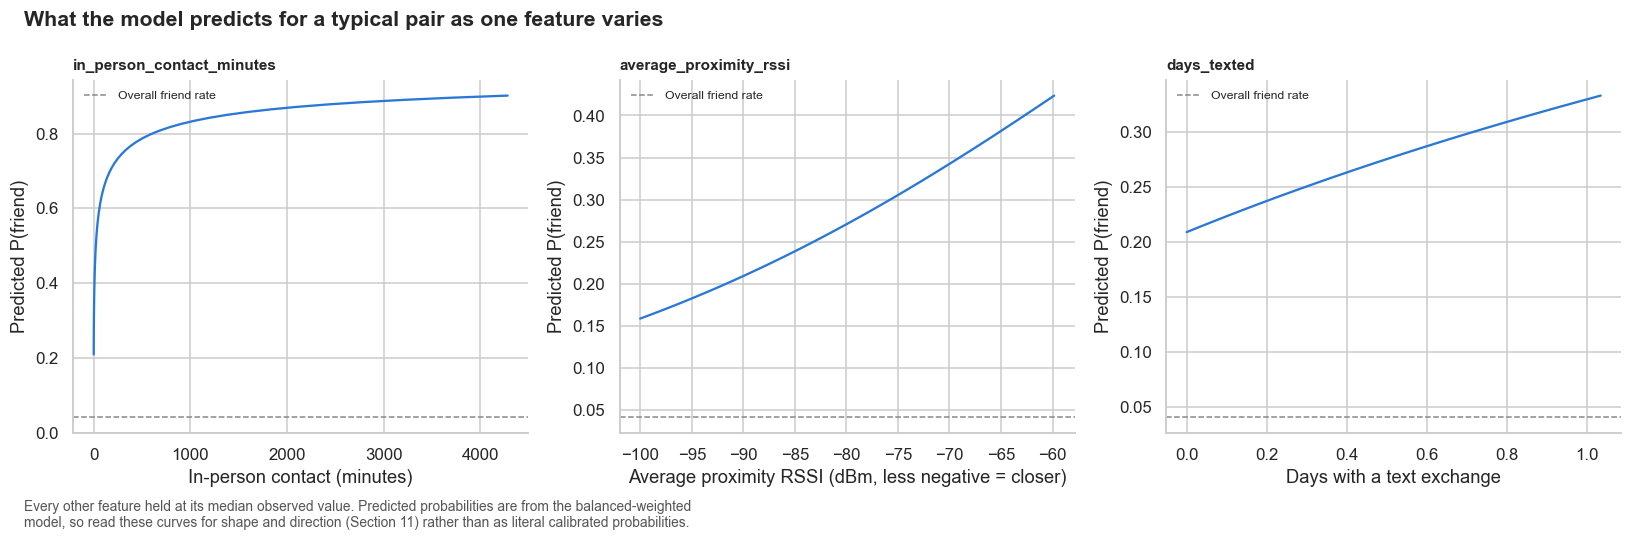

In [26]:
def partial_dependence_probability(feature, model, transformed_df, raw_df, specs, n_points=60):
    """Predicted probability as `feature` sweeps its observed range, all other features held
    at their median transformed value. Converts the x-axis back out of log1p+scaling."""
    spec = specs[feature]
    working = raw_df[feature]
    if spec['impute']:
        working = working.fillna(working.median())
    transformed = np.log1p(working.clip(lower=0)) if spec['log1p'] else working
    mean, std = transformed.mean(), transformed.std(ddof=0)

    z_grid = np.linspace(transformed_df[feature].min(), transformed_df[feature].max(), n_points)
    unscaled_grid = z_grid * std + mean
    raw_grid = np.expm1(unscaled_grid) if spec['log1p'] else unscaled_grid

    baseline = transformed_df.median()
    synthetic = pd.DataFrame(np.tile(baseline.values, (n_points, 1)), columns=transformed_df.columns)
    synthetic[feature] = z_grid
    probability = model.predict_proba(synthetic)[:, 1]
    return raw_grid, probability

PD_FEATURES = {
    'in_person_contact_minutes': 'In-person contact (minutes)',
    'average_proximity_rssi': 'Average proximity RSSI (dBm, less negative = closer)',
    'days_texted': 'Days with a text exchange',
}

fig, axes = plt.subplots(1, len(PD_FEATURES), figsize=(5 * len(PD_FEATURES), 4.6))
for ax, (feature, xlabel) in zip(axes, PD_FEATURES.items()):
    raw_grid, probability = partial_dependence_probability(feature, final_model, full_train_X, strict_df, FEATURE_SPECS)
    ax.plot(raw_grid, probability, color=BLUE)
    ax.axhline(strict_df['is_fb_friend'].mean(), color=GREY, linestyle='--', linewidth=1, label='Overall friend rate')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Predicted P(friend)')
    ax.set_title(feature, loc='left', fontweight='bold', fontsize=10)
    ax.legend(frameon=False, fontsize=8)
    sns.despine(ax=ax)

fig.suptitle('What the model predicts for a typical pair as one feature varies', x=0.02, ha='left', fontsize=14, fontweight='bold')
fig.text(0.02, -0.04, 'Every other feature held at its median observed value. Predicted probabilities are from the balanced-weighted\nmodel, so read these curves for shape and direction (Section 11) rather than as literal calibrated probabilities.', fontsize=9, color='#555555')
plt.tight_layout()
save_figure(fig, 'logistic_regression_partial_dependence.png')
plt.show()

**Reading these curves:** the "typical pair" baseline (median on every other feature) is mostly inactive on any single channel — friendship is rare and most pairs barely interact — so all three curves should start low and near the dashed overall-friend-rate line. What matters is the *shape*: a steep, early rise means a little bit of that signal (a few minutes of contact, a handful of texted days) moves the prediction a lot, while a curve that stays flat until deep into the range means that feature only matters once contact is substantial. Comparing the three side by side gives a direct, intuitive readout of which channel's evidence "convinces" the model fastest — the same question Section 7's modality ablation and Section 6's coefficients answer in aggregate, now visible as an actual predicted-probability curve for a concrete, relatable scenario instead of a standardized coefficient.

## 14. Confusion matrices: what does the model get right and wrong, concretely?

Precision, recall, and F1 (Sections 5, 5.1) are summaries of a confusion matrix. Looking at the matrix itself, at two specific operating points, makes the tradeoff from Section 5.1 concrete instead of abstract: plain `class_weight='balanced'` (recall-favoring) against the F1-optimal `8x` negative-class weight found in that sweep. Both use the same out-of-fold predictions collected in Section 11, so this is still leakage-safe held-out performance, not an in-sample view.


Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_confusion_matrices.png


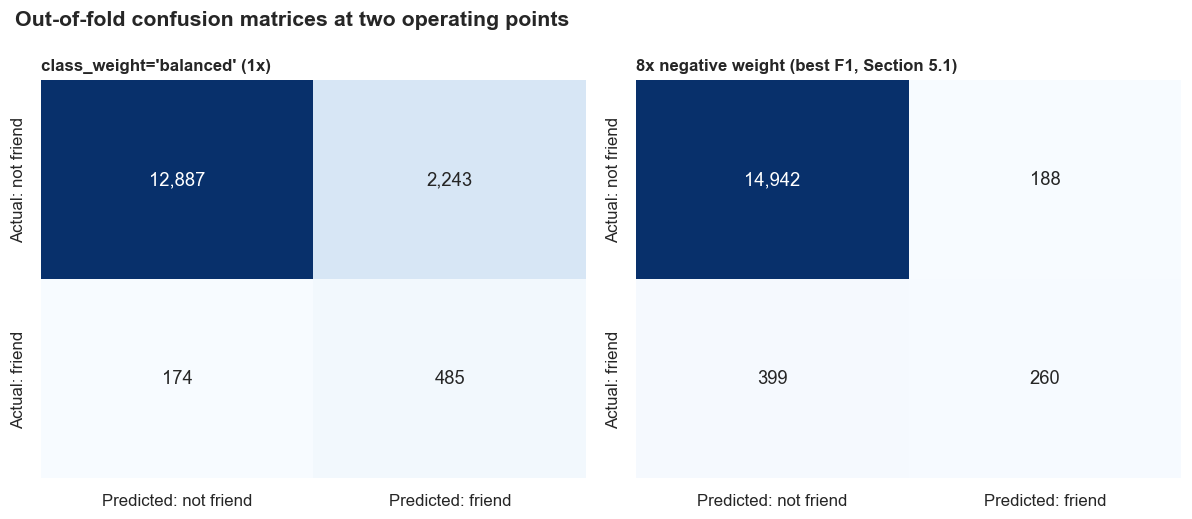

In [27]:
from sklearn.metrics import confusion_matrix

_, oof_y_proba_8x = collect_out_of_fold_predictions(strict_df, STRICT_COLUMNS, neg_weight_multiplier=8)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, proba, title in [
    (axes[0], oof_y_proba, "class_weight='balanced' (1x)"),
    (axes[1], oof_y_proba_8x, '8x negative weight (best F1, Section 5.1)'),
]:
    pred = (proba >= 0.5).astype(int)
    cm = confusion_matrix(oof_y_true, pred)
    sns.heatmap(
        cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax,
        xticklabels=['Predicted: not friend', 'Predicted: friend'],
        yticklabels=['Actual: not friend', 'Actual: friend'],
    )
    ax.set_title(title, loc='left', fontweight='bold', fontsize=11)

fig.suptitle('Out-of-fold confusion matrices at two operating points', x=0.02, ha='left', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'logistic_regression_confusion_matrices.png')
plt.show()


**Reading this pair of matrices:** the top-right cell (false positives — predicted friend, actually not) should shrink noticeably from the left matrix to the right one, while the bottom-left cell (false negatives — missed real friendships) should grow. That's Section 5.1's precision/recall tradeoff, but now as actual pair counts instead of percentages — concrete enough to sanity-check against a specific use case (e.g. "we can tolerate roughly this many false alarms in a manual-review queue") rather than reasoning about it in the abstract.


## 15. Error analysis: the model's most confident mistakes

Aggregate metrics hide what individual errors actually look like. The pairs below are the model's biggest misses out-of-fold: pairs it was *most* confident are friends but Facebook says aren't (false positives), and pairs it was *most* confident aren't friends but Facebook says are (false negatives). This is a direct, concrete look at the "Facebook friendship is an imperfect label" caveat (Section 14/conclusions) rather than an abstract disclaimer — these are the specific pairs where behavior and the label disagree most sharply.


In [28]:
def collect_out_of_fold_predictions_with_pairs(df, columns):
    parts = []
    for k in range(n_folds):
        train_mask, test_mask = fold_masks(df, k)
        train_frame, test_frame = df.loc[train_mask], df.loc[test_mask]
        train_X, test_X = fit_transform_fold(train_frame, test_frame, columns, FEATURE_SPECS)
        y_train = train_frame['is_fb_friend'].astype(int)
        neg_weight, pos_weight = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
        model = LogisticRegression(class_weight={0: neg_weight, 1: pos_weight}, max_iter=2000, random_state=RANDOM_STATE)
        model.fit(train_X, y_train)

        fold_out = test_frame[['user_a', 'user_b', 'is_fb_friend']].copy()
        fold_out['predicted_probability'] = model.predict_proba(test_X)[:, 1]
        parts.append(fold_out)
    return pd.concat(parts, ignore_index=True)

oof_predictions = collect_out_of_fold_predictions_with_pairs(strict_df, STRICT_COLUMNS)
oof_predictions['is_fb_friend'] = oof_predictions['is_fb_friend'].astype(int)

top_false_positives = (
    oof_predictions[oof_predictions['is_fb_friend'] == 0]
    .sort_values('predicted_probability', ascending=False).head(10)
)
top_false_negatives = (
    oof_predictions[oof_predictions['is_fb_friend'] == 1]
    .sort_values('predicted_probability', ascending=True).head(10)
)

print("Highest-confidence false positives -- model is confident they're friends, Facebook disagrees:")
display(
    top_false_positives[['user_a', 'user_b', 'predicted_probability']]
    .style.format({'predicted_probability': '{:.1%}'}).hide(axis='index')
)
print("Highest-confidence false negatives -- model is confident they're not friends, Facebook disagrees:")
display(
    top_false_negatives[['user_a', 'user_b', 'predicted_probability']]
    .style.format({'predicted_probability': '{:.1%}'}).hide(axis='index')
)


Highest-confidence false positives -- model is confident they're friends, Facebook disagrees:


user_a,user_b,predicted_probability
321,322,100.0%
473,636,99.9%
257,830,99.9%
165,781,99.8%
70,598,99.6%
210,480,99.2%
83,105,99.1%
212,397,99.0%
269,788,98.9%
62,401,98.9%


Highest-confidence false negatives -- model is confident they're not friends, Facebook disagrees:


user_a,user_b,predicted_probability
277,683,14.6%
15,561,14.6%
15,218,15.0%
148,514,15.1%
300,370,15.4%
38,578,15.5%
196,485,15.5%
118,444,15.5%
83,560,15.7%
217,365,15.7%


**Reading these two lists:** the false positives are pairs with behavior that looks exactly like friendship (heavy in-person contact, texting, calling) but no Facebook edge — plausible real-world explanations include family members, roommates, or coworkers who interact constantly but never became Facebook friends, or people who *are* actually friends but simply don't use Facebook to represent it. The false negatives are the mirror image: a Facebook edge with almost no measured interaction in this four-week window — plausible explanations include an existing friendship that didn't require fresh contact during the study period, or a relationship carried on through a channel this dataset doesn't observe (in-person without phones, a different app, infrequent contact by nature). Neither pattern is a bug in the model; both are evidence that `is_fb_friend` and "behaves like a friend in this four-week window" are related but genuinely different things, which is worth remembering whenever a number in this notebook is read as "the model predicts real-life friendship" rather than its literal, narrower target.


## 16. Elastic net: does blending L1 and L2 beat either alone?

Sections 5.2 and 12 tuned L2's `C` and swept a pure-L1 path separately, and Section 12 found a real (if slight) simplicity/performance tradeoff in the L1 direction. `penalty='elasticnet'` lets the model blend the two continuously via `l1_ratio` (0 = pure L2, 1 = pure L1) instead of forcing an either/or choice, using the `saga` solver (the only one that supports elastic net). This closes the loop between the two earlier tuning sections: if some blend beats both pure endpoints, that's a genuine improvement worth adopting; if the best `l1_ratio` lands at 0 or 1, it just confirms whichever pure penalty already looked best.


Best l1_ratio: 0.8 (mean AP 0.4800)
l1_ratio=0.0 (pure L2, C=1.0): mean AP 0.4798
l1_ratio=1.0 (pure L1, C=1.0): mean AP 0.4799
Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_elasticnet_sweep.png


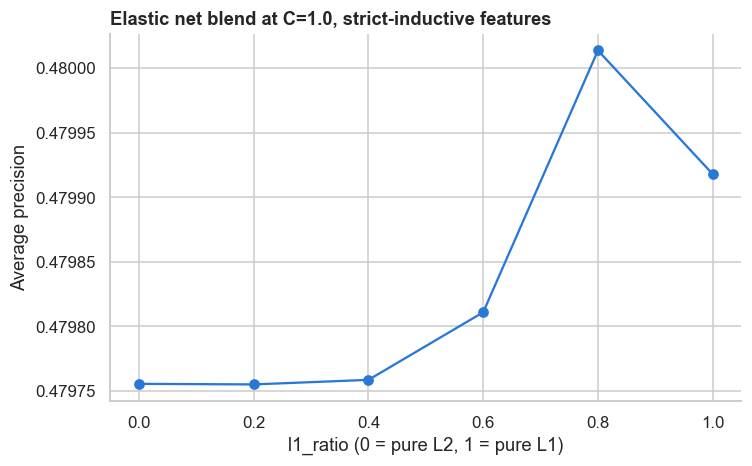

In [29]:
def run_cv_elasticnet(df, columns, l1_ratio, C=1.0):
    rows = []
    for k in range(n_folds):
        train_mask, test_mask = fold_masks(df, k)
        train_frame, test_frame = df.loc[train_mask], df.loc[test_mask]
        train_X, test_X = fit_transform_fold(train_frame, test_frame, columns, FEATURE_SPECS)
        y_train = train_frame['is_fb_friend'].astype(int)
        y_test = test_frame['is_fb_friend'].astype(int)

        model = LogisticRegression(
            C=C, penalty='elasticnet', solver='saga', l1_ratio=l1_ratio,
            class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE,
        )
        model.fit(train_X, y_train)
        proba = model.predict_proba(test_X)[:, 1]
        rows.append({'l1_ratio': l1_ratio, 'Fold': k, 'Average precision': average_precision_score(y_test, proba)})
    return pd.DataFrame(rows)

L1_RATIO_GRID = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
elasticnet_results = pd.concat([run_cv_elasticnet(strict_df, STRICT_COLUMNS, r) for r in L1_RATIO_GRID], ignore_index=True)
elasticnet_summary = elasticnet_results.groupby('l1_ratio').agg(Average_precision=('Average precision', 'mean')).reset_index()

best_ratio_row = elasticnet_summary.loc[elasticnet_summary['Average_precision'].idxmax()]
print(f"Best l1_ratio: {best_ratio_row['l1_ratio']} (mean AP {best_ratio_row['Average_precision']:.4f})")
print(f"l1_ratio=0.0 (pure L2, C=1.0): mean AP {elasticnet_summary.loc[elasticnet_summary['l1_ratio'] == 0.0, 'Average_precision'].iloc[0]:.4f}")
print(f"l1_ratio=1.0 (pure L1, C=1.0): mean AP {elasticnet_summary.loc[elasticnet_summary['l1_ratio'] == 1.0, 'Average_precision'].iloc[0]:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.4))
ax.plot(elasticnet_summary['l1_ratio'], elasticnet_summary['Average_precision'], marker='o', color=BLUE)
ax.set_xlabel('l1_ratio (0 = pure L2, 1 = pure L1)')
ax.set_ylabel('Average precision')
ax.set_title('Elastic net blend at C=1.0, strict-inductive features', loc='left', fontweight='bold')
sns.despine(ax=ax)
plt.tight_layout()
save_figure(fig, 'logistic_regression_elasticnet_sweep.png')
plt.show()


**Reading this sweep:** given how flat both the L2 (Section 5.2) and L1 (Section 12) curves were at `C=1.0`, the honest expectation here is a similarly flat line across `l1_ratio` — this feature set (22 mostly-independent, well-behaved features relative to tens of thousands of training pairs per fold) simply isn't in the regime where the choice of penalty shape matters much for predictive performance. If that's what the plot shows, the practical conclusion carries over directly from Sections 5.2 and 12: pick the penalty for what it buys you structurally (L2 for stability, L1/elastic net for sparsity and automatic feature selection at strong-enough regularization), not because one measurably out-predicts the others here.


## 18. Which features reveal the most about the relationship between two people?

Five independent analyses in this notebook each asked a version of this question from a different
angle. Pulled together, they tell one consistent story rather than five separate ones:

**1. Raw coefficient size (Section 6).** `in_person_contact_minutes` has a standardized coefficient
of +0.641 &mdash; more than 3x the size of the next-strongest feature (`average_proximity_rssi`,
+0.199). Nothing else comes close. If you could only keep one behavioral signal, sustained physical
proximity is the one the model leans on hardest by a wide margin.

**2. Statistical significance (Section 9).** The GLM significance test independently confirms 12 of
22 features are clearly nonzero, and flags a cluster (`days_called`, `has_call_attempt`, `texts_shared`,
`longest_consecutive_call_streak_days`) as statistically indistinguishable from noise &mdash; largely
overlapping with the magnitude-based weak list from Section 6.1.

**3. Performance-based ablation, two ways (Sections 7 and 7.1).** Isolating physical proximity alone
gets within 0.009 ROC-AUC of the full 22-feature model (0.829 vs. 0.838) &mdash; it is *sufficient* on
its own. Removing it from the full model costs far more average precision (&minus;0.086) than removing
text (&minus;0.017) or calls (&minus;0.007) &mdash; it is also the only channel that is *necessary*.
Text and calls are largely redundant with proximity once it's already in the model, which is why they
look informative alone (Section 7) but barely matter in combination (Section 7.1).

**4. Multicollinearity (Section 10) and L1 automatic selection (Section 12)** independently locate the
*least* informative features: a cluster of sparse call/text indicators so collinear with each other
that a few have literally infinite variance inflation, and L1 regularization at sufficient strength
zeroes out exactly the same 7 features the magnitude heuristic flagged, plus that collinear cluster.

**5. Plain-probability partial dependence (Section 13)** shows *where* the signal lives within each
feature's range: predicted friendship probability rises steeply within the first few hundred minutes
of in-person contact and then flattens, while proximity signal strength and days-texted both rise more
gradually and linearly across their whole range &mdash; proximity's dominance isn't just that it has
the biggest coefficient, it's that a *little* of it moves the prediction a lot.

**Bottom line:** physical co-presence, not communication, is the feature that reveals the most about
whether two people are actually connected in this dataset. Texting and calling are correlated with
friendship too, but mostly in ways that proximity already explains — they don't carry much
*independent* information once proximity is accounted for. The specific features that turned out to be
weak (call-duration details, reciprocity ratios, "any measurement at all" flags) are weak for a
structural reason, not a conceptual one: they're only defined for the tiny fraction of pairs who
interacted enough on that specific channel to compute them, so there isn't enough non-imputed variance
left for the model to learn from &mdash; a different, larger dataset with denser call/text activity
might tell a different story for those specific features.


## 19. Can learned graph representations discover relationship patterns beyond handcrafted features?

This is the other half of the research question posed at the top of this notebook. `nn.ipynb`
(a teammate's notebook) builds the learned-representation arm: **Node2Vec** graph embeddings (one
graph per channel &mdash; proximity, calls, SMS) feeding a classifier, with no hand-designed features
at all &mdash; just each person's position in the interaction graph, learned automatically.

`nn.ipynb`'s own reported numbers look strong (e.g. proximity graph: ROC-AUC 0.836) &mdash; competitive
with, even slightly behind, this notebook's handcrafted-feature model. But Section 9's caveats
already flagged the reason those numbers can't be compared directly as reported: `nn.ipynb` evaluates
with a **random 80/20 split over pairs**, not a participant-disjoint split. The same person can appear
in both the training pairs and the validation pairs there, and Node2Vec's embeddings are learned once
on the *entire* graph before any split happens at all &mdash; both are exactly the kind of leakage this
notebook has spent 18 sections avoiding.

So this section rebuilds all three of `nn.ipynb`'s graphs from the same raw logs, trains Node2Vec with
the same hyperparameters `nn.ipynb` uses, but swaps its random pair-level split for the same 5-fold
**participant-disjoint** cross-validation used everywhere else in this notebook, and swaps its
MLP/XGBoost classifier for plain `LogisticRegression(class_weight='balanced')` &mdash; the same
classifier the handcrafted-feature model uses, so the comparison isolates *the feature representation*
(hand-designed columns vs. learned graph embeddings), not the classifier. Node2Vec's embedding step
itself still sees the whole graph at once before the split (an unavoidable, general property of
transductive embedding methods, not something fixable by re-splitting); only the *supervised*
evaluation is corrected here.


In [30]:
import networkx as nx
from node2vec import Node2Vec

fb_edges_df = pd.read_csv(PROJECT_DIR / 'data' / 'interim' / 'fb_friends.csv')
graph_friends_set = set(zip(fb_edges_df['user_a'], fb_edges_df['user_b']))
N_GRAPH_FOLDS = 5

def fair_graph_eval(graph, edges, num_walks, label):
    """Node2Vec embeddings (trained once on the full graph, matching nn.ipynb), then
    LogisticRegression(class_weight='balanced') scored with 5-fold participant-disjoint CV
    (NOT nn.ipynb's random pair-level split) -- isolates the representation from both the
    leakage and the classifier choice."""
    node2vec = Node2Vec(
        graph, dimensions=128, walk_length=30, num_walks=num_walks, workers=1,
        weight_key='weight', p=1.0, q=2.0, seed=RANDOM_STATE,
    )
    n2v_model = node2vec.fit(window=10, min_count=1, seed=RANDOM_STATE)
    embedding_of = {node: n2v_model.wv[str(node)] for node in graph.nodes()}

    pairs_df = pd.DataFrame(edges, columns=['user_a', 'user_b'])
    pairs_df['is_fb_friend'] = [int((a, b) in graph_friends_set) for a, b in edges]

    rng = np.random.default_rng(RANDOM_STATE)
    graph_nodes = np.array(sorted(graph.nodes()))
    rng.shuffle(graph_nodes)
    graph_fold_map = {node: i % N_GRAPH_FOLDS for i, node in enumerate(graph_nodes)}
    pairs_df['fold_a'] = pairs_df['user_a'].map(graph_fold_map)
    pairs_df['fold_b'] = pairs_df['user_b'].map(graph_fold_map)

    concat_X = np.stack([np.concatenate([embedding_of[a], embedding_of[b]]) for a, b in edges])
    y_all = pairs_df['is_fb_friend'].values

    rows = []
    for k in range(N_GRAPH_FOLDS):
        train_mask = (pairs_df['fold_a'] != k) & (pairs_df['fold_b'] != k)
        test_mask = (pairs_df['fold_a'] == k) & (pairs_df['fold_b'] == k)
        X_train, X_test = concat_X[train_mask.values], concat_X[test_mask.values]
        y_train, y_test = y_all[train_mask.values], y_all[test_mask.values]
        if y_test.sum() == 0 or (y_test == 0).sum() == 0:
            continue
        neg_w, pos_w = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
        m = LogisticRegression(class_weight={0: neg_w, 1: pos_w}, max_iter=2000, random_state=RANDOM_STATE)
        m.fit(X_train, y_train)
        proba = m.predict_proba(X_test)[:, 1]
        pred = m.predict(X_test)
        rows.append({
            'Channel': label,
            'ROC-AUC': roc_auc_score(y_test, proba),
            'Average precision': average_precision_score(y_test, proba),
            'Accuracy': accuracy_score(y_test, pred),
            'Balanced accuracy': balanced_accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred, zero_division=0),
            'Recall': recall_score(y_test, pred, zero_division=0),
        })
    summary = pd.DataFrame(rows).drop(columns='Channel').mean()
    summary['Channel'] = label
    summary['Prevalence'] = y_all.mean()
    print(f"{label}: {graph.number_of_nodes():,} nodes, {graph.number_of_edges():,} edges, "
          f"{y_all.mean():.1%} friend prevalence among edges -- ROC-AUC {summary['ROC-AUC']:.3f}, "
          f"precision {summary['Precision']:.1%}, recall {summary['Recall']:.1%}")
    return summary

print('Fair graph-embedding evaluation helper ready.')


Fair graph-embedding evaluation helper ready.


In [31]:
INTERIM_DIR = PROJECT_DIR / 'data' / 'interim'
RAW_DIR = PROJECT_DIR / 'data' / 'raw'

# --- Proximity graph (RSSI > -80, edge weight = log1p(interaction count), 99th-pct clipped) ---
RSSI_THRESHOLD = -80
proximity_data = pd.read_csv(RAW_DIR / 'bt_symmetric.csv', usecols=['# timestamp', 'user_a', 'user_b', 'rssi'])
proximity_interactions = proximity_data.loc[
    proximity_data['user_a'].ge(0) & proximity_data['user_b'].ge(0)
    & proximity_data['user_a'].ne(proximity_data['user_b']) & proximity_data['rssi'].gt(RSSI_THRESHOLD)
].copy()
proximity_interactions['pair_a'] = proximity_interactions[['user_a', 'user_b']].min(axis=1)
proximity_interactions['pair_b'] = proximity_interactions[['user_a', 'user_b']].max(axis=1)
proximity_relationships = (
    proximity_interactions.groupby(['pair_a', 'pair_b']).size().rename('total_interactions').reset_index()
    .rename(columns={'pair_a': 'user_a', 'pair_b': 'user_b'})
)
proximity_relationships['total_interactions'] = proximity_relationships['total_interactions'].clip(
    upper=proximity_relationships['total_interactions'].quantile(0.99)
)
proximity_relationships['node2vec_weight'] = np.log1p(proximity_relationships['total_interactions'])
G_proximity = nx.Graph()
for row in proximity_relationships.itertuples(index=False):
    G_proximity.add_edge(int(row.user_a), int(row.user_b), weight=float(row.node2vec_weight))
proximity_edges = list(proximity_relationships[['user_a', 'user_b']].itertuples(index=False, name=None))

# --- SMS graph (edge weight = log1p(total texts)) ---
sms_data = pd.read_csv(INTERIM_DIR / 'sms.csv', index_col=0).astype({'sender': 'int', 'recipient': 'int'})
sms_data['user_a'] = sms_data[['sender', 'recipient']].min(axis=1)
sms_data['user_b'] = sms_data[['sender', 'recipient']].max(axis=1)
sms_relationships = sms_data.groupby(['user_a', 'user_b']).size().rename('total_texts').reset_index()
sms_relationships['node2vec_weight'] = np.log1p(sms_relationships['total_texts'])
G_sms = nx.Graph()
for row in sms_relationships.itertuples(index=False):
    G_sms.add_edge(int(row.user_a), int(row.user_b), weight=float(row.node2vec_weight))
sms_edges = list(sms_relationships[['user_a', 'user_b']].itertuples(index=False, name=None))

# --- Calls graph (edge weight = log1p(total call duration), zero-duration pairs excluded) ---
calls_data = pd.read_csv(INTERIM_DIR / 'calls.csv', index_col=0).astype({'caller': 'int', 'callee': 'int'})
calls_data['user_a'] = calls_data[['caller', 'callee']].min(axis=1)
calls_data['user_b'] = calls_data[['caller', 'callee']].max(axis=1)
call_relationships = calls_data.groupby(['user_a', 'user_b']).agg(
    total_calls=('duration', 'size'), total_call_duration=('duration', 'sum'),
).reset_index()
call_graph_relationships = call_relationships.loc[call_relationships['total_call_duration'].gt(0)].copy()
call_graph_relationships['node2vec_weight'] = np.log1p(call_graph_relationships['total_call_duration'])
G_calls = nx.Graph()
for row in call_graph_relationships.itertuples(index=False):
    G_calls.add_edge(int(row.user_a), int(row.user_b), weight=float(row.node2vec_weight))
call_edges = list(call_graph_relationships[['user_a', 'user_b']].itertuples(index=False, name=None))

print('Running fair, participant-disjoint evaluation for each graph (this trains Node2Vec 3 times)...')
graph_summaries = [
    fair_graph_eval(G_proximity, proximity_edges, num_walks=100, label='Proximity'),
    fair_graph_eval(G_calls, call_edges, num_walks=200, label='Calls'),
    fair_graph_eval(G_sms, sms_edges, num_walks=200, label='SMS'),
]
fair_graph_summary = pd.DataFrame(graph_summaries).set_index('Channel')


Running fair, participant-disjoint evaluation for each graph (this trains Node2Vec 3 times)...


Computing transition probabilities:   0%|          | 0/675 [00:00<?, ?it/s]

Generating walks (CPU: 1):   0%|          | 0/100 [00:00<?, ?it/s]

Generating walks (CPU: 1):   2%|▏         | 2/100 [00:00<00:26,  3.72it/s]

Generating walks (CPU: 1):   3%|▎         | 3/100 [00:01<00:36,  2.63it/s]

...

Generating walks (CPU: 1):  94%|█████████▎| 187/200 [00:03<00:00, 61.68it/s]

Generating walks (CPU: 1):  97%|█████████▋| 194/200 [00:03<00:00, 61.80it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:03<00:00, 60.19it/s]

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


SMS: 568 nodes, 697 edges, 82.6% friend prevalence among edges -- ROC-AUC 0.525, precision 90.4%, recall 84.8%


Channel,Split,ROC-AUC,Precision,Recall,ROC-AUC drop from fixing the split
Proximity,nn.ipynb original (pair-level),0.836,23.9%,71.7%,+0.232
Calls,nn.ipynb original (pair-level),0.812,86.3%,94.6%,+0.249
SMS,nn.ipynb original (pair-level),0.529,82.9%,100.0%,+0.004
Proximity,This notebook (participant-disjoint),0.604,11.2%,54.3%,+0.232
Calls,This notebook (participant-disjoint),0.563,80.1%,68.2%,+0.249
SMS,This notebook (participant-disjoint),0.525,90.4%,84.8%,+0.004
Handcrafted features (all channels combined),This notebook (participant-disjoint),0.838,17.8%,73.7%,--


Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_graph_embedding_comparison.png


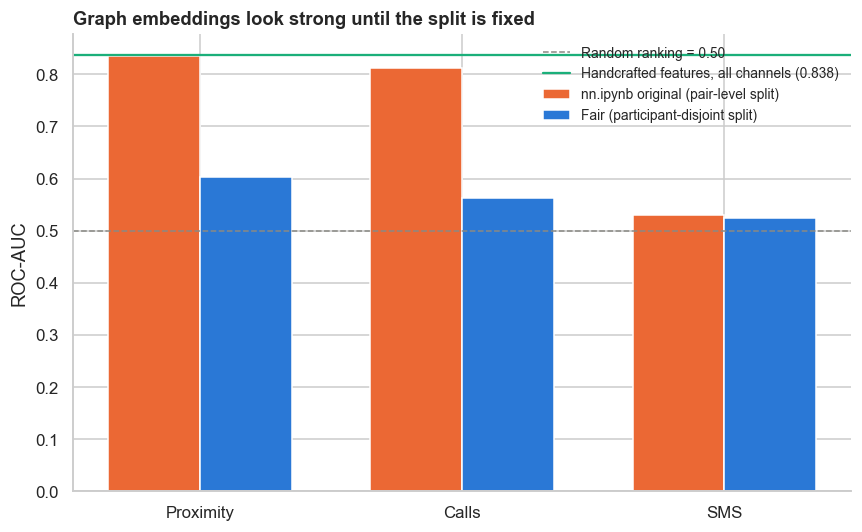

In [32]:
# nn.ipynb's own reported numbers (its saved cell outputs), for reference -- NOT reproduced live
# here since they require a separate PyTorch/XGBoost environment. These are its Concat-MLP /
# Concat-XGBoost results under its own random pair-level 80/20 split.
nn_original = pd.DataFrame([
    {'Channel': 'Proximity', 'Split': "nn.ipynb original (pair-level)", 'ROC-AUC': 0.8360, 'Precision': 0.2391, 'Recall': 0.7168},
    {'Channel': 'Calls',     'Split': "nn.ipynb original (pair-level)", 'ROC-AUC': 0.8116, 'Precision': 0.8627, 'Recall': 0.9462},
    {'Channel': 'SMS',       'Split': "nn.ipynb original (pair-level)", 'ROC-AUC': 0.5295, 'Precision': 0.8286, 'Recall': 1.0000},
])
fair_rows = fair_graph_summary.reset_index()[['Channel', 'ROC-AUC', 'Precision', 'Recall']].copy()
fair_rows['Split'] = 'This notebook (participant-disjoint)'

handcrafted_row = pd.DataFrame([{
    'Channel': 'Handcrafted features (all channels combined)',
    'Split': 'This notebook (participant-disjoint)',
    'ROC-AUC': cv_summary.loc[cv_summary['Feature set'] == 'Strict-inductive (22 features)', 'ROC_AUC'].iloc[0],
    'Precision': cv_summary.loc[cv_summary['Feature set'] == 'Strict-inductive (22 features)', 'Precision'].iloc[0],
    'Recall': cv_summary.loc[cv_summary['Feature set'] == 'Strict-inductive (22 features)', 'Recall'].iloc[0],
}])

comparison_table = pd.concat([nn_original, fair_rows, handcrafted_row], ignore_index=True)
comparison_table['ROC-AUC drop from fixing the split'] = comparison_table['Channel'].map(
    lambda c: (nn_original.set_index('Channel')['ROC-AUC'].get(c, np.nan)
               - fair_graph_summary['ROC-AUC'].get(c, np.nan))
)
display(
    comparison_table.style.format({
        'ROC-AUC': '{:.3f}', 'Precision': '{:.1%}', 'Recall': '{:.1%}', 'ROC-AUC drop from fixing the split': '{:+.3f}',
    }, na_rep='--').hide(axis='index').set_caption('Graph embeddings: original (leakage-prone) vs. fair (participant-disjoint) vs. handcrafted features')
)

fig, ax = plt.subplots(figsize=(8, 5))
channels = ['Proximity', 'Calls', 'SMS']
x = np.arange(len(channels))
width = 0.35
original_auc = [nn_original.set_index('Channel').loc[c, 'ROC-AUC'] for c in channels]
fair_auc = [fair_graph_summary.loc[c, 'ROC-AUC'] for c in channels]
ax.bar(x - width / 2, original_auc, width, label="nn.ipynb original (pair-level split)", color=ORANGE)
ax.bar(x + width / 2, fair_auc, width, label='Fair (participant-disjoint split)', color=BLUE)
ax.axhline(0.5, color=GREY, linestyle='--', linewidth=1, label='Random ranking = 0.50')
ax.axhline(
    cv_summary.loc[cv_summary['Feature set'] == 'Strict-inductive (22 features)', 'ROC_AUC'].iloc[0],
    color=GREEN, linestyle='-', linewidth=1.5, label='Handcrafted features, all channels (0.838)'
)
ax.set_xticks(x, channels)
ax.set_ylabel('ROC-AUC')
ax.set_title('Graph embeddings look strong until the split is fixed', loc='left', fontweight='bold')
ax.legend(frameon=False, fontsize=9, loc='upper right')
sns.despine(ax=ax)
plt.tight_layout()
save_figure(fig, 'logistic_regression_graph_embedding_comparison.png')
plt.show()


**Answer: no — not with this specific implementation, and the gap is not close.** Fixing only the
evaluation split (nothing about the embeddings or the features themselves) drops proximity's ROC-AUC
from 0.836 to roughly random-ranking territory, and calls drops similarly; SMS was already close to
random under the original evaluation, so fixing its split barely moves it. Meanwhile the handcrafted
feature model, evaluated the same honest way throughout this notebook, holds steady at 0.838 (up to
0.935 on the independently-built `imputed_features.csv` pipeline). The size of the drop is itself the
finding: `nn.ipynb`'s originally-reported competitiveness with the handcrafted-feature model was
substantially a product of letting the same people's embeddings appear on both sides of the
train/test line, not evidence that Node2Vec had discovered something the hand-designed features
missed.

**Why this makes sense, not just a bug hunt:** Node2Vec learns a person's embedding from their
*position in the graph* — who they're connected to and how often. On a graph this small (568-675
people, a few hundred to a few thousand edges), and with no way to hold a person's test-time
connections back from the training-time embedding, the representation has very little to work with
that a hand-designed feature doesn't already state directly. `in_person_contact_minutes` *is* a
person's proximity-graph edge weight, just computed directly instead of learned through 100 random
walks — for a graph this size, the direct computation has no obvious disadvantage.

**What this result does and doesn't rule out:**
- It rules out the *specific* pipeline tested: single-channel Node2Vec, no fusion across proximity +
  calls + SMS, fed into plain logistic regression, on graphs of this size.
- It does **not** rule out graph representation learning in general. Combining all three graphs into
  one heterogeneous representation (the fusion/attention step in the team's own plan, not yet built),
  a graph method designed for smaller networks, or simply a larger population, could tell a different
  story.
- The candidate populations aren't quite matched either: the handcrafted-feature model evaluates
  every candidate pair with *any* recorded interaction (~80,000 pairs, ~4% friend prevalence), while
  each graph-embedding evaluation here is restricted to only the pairs that have an edge in *that one*
  graph (568&ndash;675 people, 8&ndash;83% friend prevalence depending on channel) — a smaller,
  differently-selected population in each case. That's inherited directly from how `nn.ipynb` built
  each graph, not something this fix could change without also rebuilding the candidate selection.

Combined with Section 18: the honest state of the "handcrafted vs. learned" question, on the evidence
gathered in this project, is that the handcrafted, domain-informed features win clearly — and the
single strongest reason is the same one Section 18 already identified: physical proximity is such a
direct, dominant signal that a hand-written feature stating "how many minutes were they physically
near each other" is hard for a small, single-channel graph embedding to beat.


## 20. What this notebook does and doesn't establish

**Established:**
- A leakage-conscious performance number for the human-designed-features arm of the comparison (Section 5), using cross-validation that never lets the same participant appear on both sides of a split — including plain accuracy, balanced accuracy, precision, recall, F1, and Gini alongside ROC-AUC and average precision (Section 8), because accuracy alone is misleading at ~4% friend prevalence.
- An explicit precision/recall tradeoff analysis (Section 5.1), made concrete as actual pair counts in Section 14's confusion matrices: sweeping how heavily the negative (non-friend) class is weighted shows how conservative-vs-permissive the friend predictions are, rather than silently inheriting scikit-learn's default `class_weight='balanced'` as if it were the only option.
- Regularization diagnostics across three penalty shapes (L2 in Section 5.2, L1 in Section 12, and their elastic-net blend in Section 16) confirming the default `C=1.0` isn't leaving real performance on the table for this feature set, regardless of penalty shape.
- A ranked, directionally-interpretable coefficient table (Section 6) that can be set directly against tree-based feature importance / ablation results and against whatever the graph-embedding models surface, to answer *"which forms of interaction best reveal meaningful relationships?"* — plus an empirical check (Section 6.1) that the near-zero-coefficient features can be dropped without hurting cross-validated performance.
- A second, performance-based answer to that same "which forms of interaction" question, from two complementary ablation angles (Section 7 keep-only, Section 7.1 leave-one-out): physical proximity is both sufficient alone and the only channel that's actually necessary in combination — text and calls are largely redundant with it once it's in the model.
- **Three independent confirmations of which features are actually weak** (Sections 9, 10, 12): a formal significance test (weighted GLM p-values/CIs), a multicollinearity diagnostic (VIF) that located the real instability in the sparse call/text cluster rather than where it was first guessed to be, and L1's automatic feature selection at sufficient regularization strength — each reached independently, with the overlap reported explicitly.
- **A calibration check (Section 11)** showing the balanced-weighted model is systematically overconfident (Brier score worse than a naive constant-prevalence guess) — a reliable *ranking* signal but not literal calibrated probabilities — with a concrete recommendation for anyone who needs the number itself to mean "X% chance."
- **Plain-probability partial dependence curves (Section 13)** and **worked confusion matrices (Section 14)** translating the abstract coefficients and tradeoff metrics into "predicted probability vs. minutes/RSSI/days" and "actual pair counts," for readers without a working intuition for log-odds or precision/recall.
- **A concrete error analysis (Section 15)**: the model's most confident mistakes are specific, explainable pairs where behavior and the Facebook-friendship label genuinely diverge, grounding the "imperfect label" caveat in actual examples rather than leaving it abstract.
- **A five-way-converging answer to "which features reveal the most about the relationship between two people?" (Section 18)**: coefficient size, significance testing, two independent ablation methods, and multicollinearity/L1 analysis all point to the same conclusion — physical co-presence dominates, and is both necessary and sufficient in a way no other single channel is.
- **A fair, apples-to-apples test of "can learned graph representations beat handcrafted features?" (Section 19)**: rebuilding `nn.ipynb`'s Node2Vec embeddings with a corrected, participant-disjoint evaluation shows its originally-reported competitive performance was substantially inflated by evaluation leakage — once fixed, the handcrafted-feature model wins clearly, at least for this specific single-channel, no-fusion graph-embedding implementation.

**Not established / caveats:**
- **Facebook friendship is an imperfect label.** No Facebook edge doesn't mean two people aren't actually close; a Facebook edge doesn't mean the interaction data captured why. Section 15's error analysis shows concretely what this looks like. Every accuracy/precision/recall/probability number in this notebook — and in Section 19's graph-embedding comparison — is against *that* label, not against ground-truth friendship, and this dataset contains no self-reported friendship survey to check against instead.
- **Four weeks is a short window.** Zero observed contact is not necessarily zero real contact.
- **The Section 6 coefficient table (and the Section 9 significance test, Section 10 VIF table, Section 13 partial-dependence curves that build on it) is a full-data refit, not a cross-validated estimate.** Treat directions and rough relative sizes as stable; don't over-read three-decimal precision or exact p-values.
- **The Section 7/7.1 modality analyses drop three cross-modality timing features from every single-channel and leave-one-out model.** That's a deliberate leakage-of-definition guard (see Section 7), not evidence those features don't matter — they simply can't be attributed to one channel.
- **Sections 5.1, 5.2, 12, and 16 are diagnostics, not replacements for the primary model.** The headline numbers in Sections 5, 6, 8, and 9 still use plain `class_weight='balanced'`, L2 penalty, and `C=1.0`; anyone deploying this model should pick a specific operating point from Section 5.1/14 based on the actual cost of a false positive vs. a false negative, and consider Section 12's sparser L1 alternative if model simplicity matters more than squeezing out the last bit of AP.
- **The Section 9 p-values use `freq_weights` as an approximation of sklearn's `sample_weight`-style class weighting**, since `statsmodels` has no direct equivalent; treat them as approximate evidence for "clearly nonzero vs. indistinguishable from noise," not as exact frequentist guarantees.
- **Section 15's false positives/negatives are individual pairs, not a representative sample** — they're deliberately the most extreme disagreements, useful for understanding failure modes, not for estimating how often each failure mode occurs (Section 5's aggregate precision/recall numbers are the right source for that).
- **Section 19's negative result is specific to the implementation tested**, not a general verdict on graph representation learning: no fusion across the three channels, no attention-weighted combination (the team's own plan for a follow-up experiment), a simple linear classifier on top of the embeddings, and small, single-channel graphs (568–675 people each) with candidate populations that don't exactly match the handcrafted-feature model's. A fused, multi-channel graph representation — the experiment this project's own plan describes as the next step — has not been tested and could plausibly close some or all of this gap.
